# Figure 4: Adaptive Therapy via the ABC Model

**Panel A** — ABC model: roles of A, B, C and timescale separation.

**Panel B** — Analytical derivation of growth vs. decay expressions.

**Panel C** — Growth vs. decay as a function of $T_{on}$ for fixed $T_{off}$, showing three regimes.

**Panel D** — Adaptive therapy simulation using the optimal $T_{on}$ identified in Panel C.

In [25]:
"""Shared parameters, ODE model, simulation helpers, and plotting utilities for Figure 4."""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from scipy.integrate import odeint
import sys
sys.path.insert(0, '../src')
from rpa_control.style import set_style

set_style()
plt.rcParams['text.usetex'] = False

# ======================================================================
# Plotting helpers
# ======================================================================

def clean_ax(ax):
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

def text_panel(ax, lines, fontsize=11):
    ax.axis('off')
    ax.text(0.05, 0.95, '\n'.join(lines), transform=ax.transAxes,
            fontsize=fontsize, verticalalignment='top', family='serif', linespacing=1.8)

# ======================================================================
# Parameters
# ======================================================================

mu  = 1.0
a1  = 1.0
b1  = 1.0   # off-treatment
b1_on = b1 / 2   # on-treatment (drug halves b1)
b2  = 2.0
c1  = 0.05   # tumor growth rate
c2  = 1.0   # tumor removal rate

# Off-treatment steady state
B_ss  = mu
A_ss  = b2 * mu / b1
A_ss_on = b2 * mu / b1_on

# On-treatment eigenvalues (A-B subsystem)
disc = b2**2 - 4 * a1 * b1_on
lam1 = (-b2 + np.sqrt(disc)) / 2   # less negative
lam2 = (-b2 - np.sqrt(disc)) / 2   # more negative

# K1 constant for B(t) during treatment
K1 = b2 * mu * (b1_on / b1 - 1) / (lam1 - lam2)

print(f'Off-treatment SS:  A={A_ss:.2f}, B={B_ss:.2f}')
print(f'On-treatment  SS:  A={A_ss_on:.2f}, B={B_ss:.2f}')
print(f'Eigenvalues:  lambda1={lam1:.4f},  lambda2={lam2:.4f}')
print(f'K1 = {K1:.4f}')
S_inf = -c2 * K1 * (-1/lam1 + 1/lam2)
print(f'S_inf = {S_inf:.4f}  (max possible decay per cycle)')

# ======================================================================
# ODE definition
# ======================================================================

def abc_rhs(t, y, b1_val):
    A, B, C = y
    dA = a1 * (mu - B)
    dB = b1_val * A - b2 * B
    dC = C * (c1 - c2 * max(mu - B, 0.0))
    return [dA, dB, dC]

# ======================================================================
# Analytical decay integral S(Ton)
# ======================================================================

def decay_analytic(Ton_arr, T_off):
    """Analytic cumulative tumor decay over one cycle as a function of Ton."""
    Ton_arr = np.asarray(Ton_arr)
    S = -c2 * K1 * (
        np.exp(lam1 * Ton_arr) / lam1
        - np.exp(lam2 * Ton_arr) / lam2
        - 1.0 / lam1
        + 1.0 / lam2
    )
    return S

def growth_analytic(Ton_arr, T_off):
    """Cumulative tumor growth over one cycle (Ton + Toff)."""
    return c1 * (np.asarray(Ton_arr) + T_off)

Off-treatment SS:  A=2.00, B=1.00
On-treatment  SS:  A=4.00, B=1.00
Eigenvalues:  lambda1=-0.2929,  lambda2=-1.7071
K1 = -0.7071
S_inf = 2.0000  (max possible decay per cycle)


**Panel A** — ABC system diagram and biological roles.

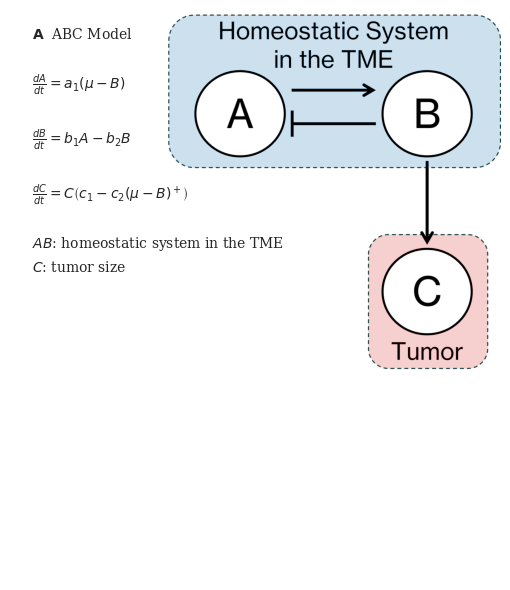

In [26]:
# Panel A: standalone — ABC system diagram + roles
import os

fig_A, ax_A = plt.subplots(figsize=(5, 6))
ax_A.axis('off')

lines_A = [
    r'$\mathbf{A}$  ABC Model',
    '',
    r'$\frac{dA}{dt} = a_1(\mu - B)$',
    '',
    r'$\frac{dB}{dt} = b_1 A - b_2 B$',
    '',
    r'$\frac{dC}{dt} = C\left(c_1 - c_2(\mu-B)^+\right)$',
    '',
    r'$AB$: homeostatic system in the TME',
    r'$C$: tumor size',
]
ax_A.text(0.05, 0.97, '\n'.join(lines_A), transform=ax_A.transAxes,
          fontsize=10, va='top', family='serif', linespacing=1.6)

ABC_IMG = 'abc_model.png'
if os.path.exists(ABC_IMG):
    ax_img = ax_A.inset_axes([0.25, 0.35, 1.0, 0.65])
    ax_img.imshow(plt.imread(ABC_IMG))
    ax_img.axis('off')

plt.tight_layout()
plt.show()


**Panel B** — Key analytical results: growth vs. decay expressions.

(Full derivation is in the Supplementary Information.)

/tmp/ipykernel_2807486/2723493984.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


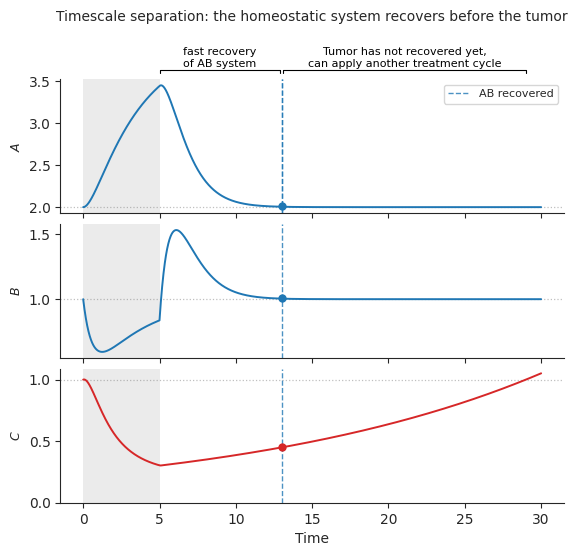

In [27]:
# ======================================================================
# Panel B: timescale separation — AB recovers before C
# ======================================================================
from scipy.optimize import brentq
from matplotlib.transforms import ScaledTranslation, blended_transform_factory

Ton_B  = 5.0
Toff_B = 25.0
C0_B   = 1.0
epsilon = 0.1
y0_B   = [A_ss, B_ss, C0_B]

_t_on  = np.linspace(0, Ton_B, 2000)
_sol_on = odeint(lambda y, t: abc_rhs(t, y, b1_on), y0_B, _t_on)
_t_off  = np.linspace(0, Toff_B, 2000)
_sol_off = odeint(lambda y, t: abc_rhs(t, y, b1), list(_sol_on[-1]), _t_off)

t_B = np.concatenate([_t_on, Ton_B + _t_off[1:]])
A_B = np.concatenate([_sol_on[:, 0], _sol_off[1:, 0]])
B_B = np.concatenate([_sol_on[:, 1], _sol_off[1:, 1]])
C_B = np.concatenate([_sol_on[:, 2], _sol_off[1:, 2]])

_imin = C_B.argmin()
_t_after = t_B[_imin:]; _C_after = C_B[_imin:]
_sc = np.where(np.diff(np.sign(_C_after - C0_B)) > 0)[0]
t_C_rec_B = brentq(lambda t: np.interp(t, t_B, C_B) - C0_B,
                   _t_after[_sc[0]], _t_after[_sc[0]+1])

t_AB_mark = 13.0

# ── Plot ──────────────────────────────────────────────────────────────
fig_B, axes_B = plt.subplots(3, 1, figsize=(6.5, 5.5), sharex=True,
                              gridspec_kw={'hspace': 0.08})
_nudge_B = ScaledTranslation(0, 0.5/72, fig_B.dpi_scale_trans)
_trans_B = lambda ax: ax.transData + _nudge_B

for ax in axes_B:
    ax.axvspan(0, Ton_B, color='lightgray', alpha=0.45, lw=0, zorder=0)
    clean_ax(ax)

axes_B[0].axhline(A_ss,  color='gray', ls=':', lw=0.9, alpha=0.5)
axes_B[1].axhline(mu,    color='gray', ls=':', lw=0.9, alpha=0.5)
axes_B[2].axhline(C0_B,  color='gray', ls=':', lw=0.9, alpha=0.5)

axes_B[0].plot(t_B, A_B, color='C0', lw=1.4)
axes_B[1].plot(t_B, B_B, color='C0', lw=1.4)
axes_B[2].plot(t_B, C_B, color='C3', lw=1.4)

# Vertical line: AB recovered
for ax in axes_B:
    ax.axvline(t_AB_mark, color='C0', ls='--', lw=1.0, alpha=0.8)
axes_B[0].axvline(t_AB_mark, color='C0', ls='--', lw=1.0, alpha=0.8, label='AB recovered')
axes_B[0].plot(t_AB_mark, np.interp(t_AB_mark, t_B, A_B), 'o', color='C0', ms=6, zorder=6, mec='none', transform=_trans_B(axes_B[0]))
axes_B[1].plot(t_AB_mark, np.interp(t_AB_mark, t_B, B_B), 'o', color='C0', ms=6, zorder=6, mec='none', transform=_trans_B(axes_B[1]))
axes_B[2].plot(t_AB_mark, np.interp(t_AB_mark, t_B, C_B), 'o', color='C3', ms=6, zorder=6, mec='none', transform=_trans_B(axes_B[2]))

# Bracket annotations above top subplot
_bt_B = blended_transform_factory(axes_B[0].transData, axes_B[0].transAxes)
_y_bar, _tick_h = 1.07, 0.025

def _draw_bracket(ax, x1, x2, text, y_bar, tick_h, trans, fs=8):
    for _xb in [x1, x2]:
        ax.plot([_xb, _xb], [y_bar - tick_h, y_bar], 'k-', lw=0.8,
                transform=trans, clip_on=False)
    ax.plot([x1, x2], [y_bar, y_bar], 'k-', lw=0.8,
            transform=trans, clip_on=False)
    ax.text((x1 + x2) / 2, y_bar + 0.01, text,
            ha='center', va='bottom', fontsize=fs, color='k',
            transform=trans, clip_on=False)

_draw_bracket(axes_B[0], Ton_B, t_AB_mark - epsilon,
              'fast recovery\nof AB system',
              _y_bar, _tick_h, _bt_B)
_draw_bracket(axes_B[0], t_AB_mark + epsilon, t_C_rec_B,
              'Tumor has not recovered yet,\ncan apply another treatment cycle',
              _y_bar, _tick_h, _bt_B)

axes_B[0].set_ylabel('$A$', fontsize=9)
axes_B[1].set_ylabel('$B$', fontsize=9)
axes_B[2].set_ylabel('$C$', fontsize=9)
axes_B[2].set_xlabel('Time', fontsize=10)
axes_B[0].legend(fontsize=8, loc='upper right')
axes_B[2].set_ylim(bottom=0)
axes_B[0].tick_params(labelbottom=False)
axes_B[1].tick_params(labelbottom=False)

axes_B[0].set_title(
    r'Timescale separation: the homeostatic system recovers before the tumor',
    fontsize=10, pad=42)

plt.tight_layout()
plt.show()


**Panel C** — Growth vs. decay for fixed $T_{off}$, with the three regimes annotated.

T_off = 13.0
Crossing points (growth = decay): ['2.259', '26.982']
Ton that maximises net decay: 9.057


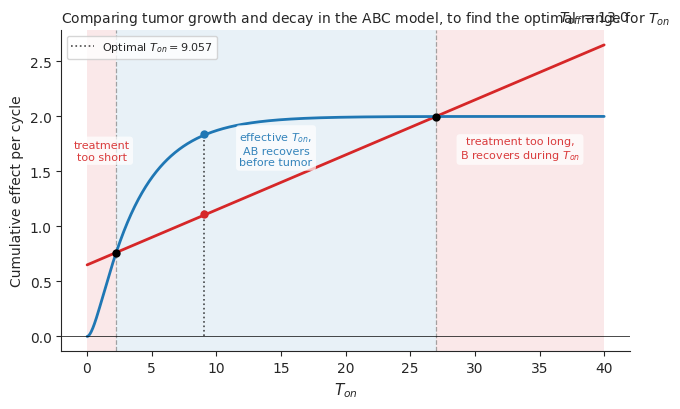


Using Ton_opt = 9.057 for Panel D


In [28]:
# ======================================================================
# Panel C: growth vs. decay with 3-regime annotations
# ======================================================================
from scipy.optimize import brentq

T_OFF = 13.0
Ton_arr = np.linspace(0.01, 40, 1000)

growth_arr = growth_analytic(Ton_arr, T_OFF)
decay_arr  = decay_analytic(Ton_arr, T_OFF)
net_arr    = decay_arr - growth_arr   # positive → tumor shrinks

# Find the two crossing points (decay == growth)
sign_changes = np.where(np.diff(np.sign(net_arr)))[0]
crossings = []
crossings_visual = []   # (x, y) on the drawn piecewise-linear curves
for idx in sign_changes:
    ta, tb = Ton_arr[idx], Ton_arr[idx + 1]
    root = brentq(lambda t: decay_analytic(t, T_OFF) - growth_analytic(t, T_OFF), ta, tb)
    crossings.append(root)
    _frac = -net_arr[idx] / (net_arr[idx+1] - net_arr[idx])
    _cx_v = ta + _frac * (tb - ta)
    _val_v = growth_arr[idx] + _frac * (growth_arr[idx+1] - growth_arr[idx])
    crossings_visual.append((_cx_v, _val_v))

print(f'T_off = {T_OFF}')
print(f'Crossing points (growth = decay): {[f"{c:.3f}" for c in crossings]}')
Ton_max_net = Ton_arr[np.argmax(net_arr)]
print(f'Ton that maximises net decay: {Ton_max_net:.3f}')

# ── Plot ──────────────────────────────────────────────────────────────
fig_C, ax_C = plt.subplots(figsize=(6.5, 4.2))

x_max = Ton_arr[-1]
regime_alpha = 0.10
if len(crossings) >= 2:
    c1_x, c2_x = crossings[0], crossings[1]
    ax_C.axvspan(Ton_arr[0], c1_x, color='C3', alpha=regime_alpha, lw=0)
    ax_C.axvspan(c1_x,       c2_x, color='C0', alpha=regime_alpha, lw=0)
    ax_C.axvspan(c2_x,       x_max, color='C3', alpha=regime_alpha, lw=0)
    for cx in (c1_x, c2_x):
        ax_C.axvline(cx, color='gray', ls='--', lw=0.9, alpha=0.7)
elif len(crossings) == 1:
    c1_x = crossings[0]
    ax_C.axvspan(Ton_arr[0], c1_x, color='C3', alpha=regime_alpha, lw=0)
    ax_C.axvspan(c1_x,       x_max, color='C0', alpha=regime_alpha, lw=0)
    ax_C.axvline(c1_x, color='gray', ls='--', lw=0.9, alpha=0.7)

# Main curves
ax_C.plot(Ton_arr, growth_arr, color='C3', lw=2)
ax_C.plot(Ton_arr, decay_arr,  color='C0', lw=2)
ax_C.axhline(0, color='k', lw=0.5)
from matplotlib.transforms import ScaledTranslation
_nudge_C = ScaledTranslation(0, 0.5/72, fig_C.dpi_scale_trans)
_trans_C = lambda ax: ax.transData + _nudge_C


# Crossing point markers
for _cx_v, _val_v in crossings_visual:
    ax_C.plot(_cx_v, _val_v, 'o', color='k', ms=6, zorder=6, mec='none')

# Regime text annotations
_y_max    = max(growth_arr.max(), decay_arr.max())
_regime_y1 = _y_max * 0.60
_regime_y2 = _y_max * 0.58
_regime_y3 = _y_max * 0.60

if len(crossings) >= 2:
    _rx1 = (Ton_arr[0] + crossings[0]) / 2
    _rx2 = (crossings[0] + crossings[1]) / 2
    _rx3 = (crossings[1] + x_max) / 2
    ax_C.text(_rx1, _regime_y1, 'treatment\ntoo short',
              ha='center', va='bottom', fontsize=8, color='C3', alpha=0.9,
              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'))
    ax_C.text(_rx2, _regime_y2, 'effective $T_{on},$\nAB recovers\nbefore tumor',
              ha='center', va='bottom', fontsize=8, color='C0', alpha=0.9,
              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'))
    ax_C.text(_rx3, _regime_y3, 'treatment too long,\nB recovers during $T_{on}$',
              ha='center', va='bottom', fontsize=8, color='C3', alpha=0.9,
              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'))

# Vertical line at maximum net decay
# Optimal Ton: line ending at top curve, with intersection dots
_y_grow_opt = growth_analytic(Ton_max_net, T_OFF)
_y_dec_opt  = decay_analytic(Ton_max_net, T_OFF)
_y_top_opt  = max(_y_grow_opt, _y_dec_opt)
ax_C.plot([Ton_max_net, Ton_max_net], [0, _y_top_opt],
          color='k', ls=':', lw=1.2, alpha=0.7, label=rf'Optimal $T_{{on}} = ${Ton_max_net:.3f}')
ax_C.plot(Ton_max_net, _y_grow_opt, 'o', color='C3', ms=6, zorder=7, mec='none', transform=_trans_C(ax_C))
ax_C.plot(Ton_max_net, _y_dec_opt,  'o', color='C0', ms=6, zorder=7, mec='none', transform=_trans_C(ax_C))

ax_C.set_xlabel(r'$T_{on}$', fontsize=11)
ax_C.set_ylabel('Cumulative effect per cycle', fontsize=10)
ax_C.set_title(r'Comparing tumor growth and decay in the ABC model,'
               r' to find the optimal range for $T_{on}$', fontsize=10, loc='left')
ax_C.set_title(rf'$T_{{off}} = {T_OFF}$', fontsize=10, loc='right')
ax_C.legend(fontsize=8, loc='upper left')
clean_ax(ax_C)
plt.tight_layout()
plt.show()

# Store the optimal Ton for Panel D
Ton_opt_C = Ton_max_net
print(f'\nUsing Ton_opt = {Ton_opt_C:.3f} for Panel D')


**Panel C'** — Comparison of optimal vs. sub-optimal $T_{on}$ (treatment too long regime), both with $T_{off}$ from Panel C.

/tmp/ipykernel_2807486/1757161717.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


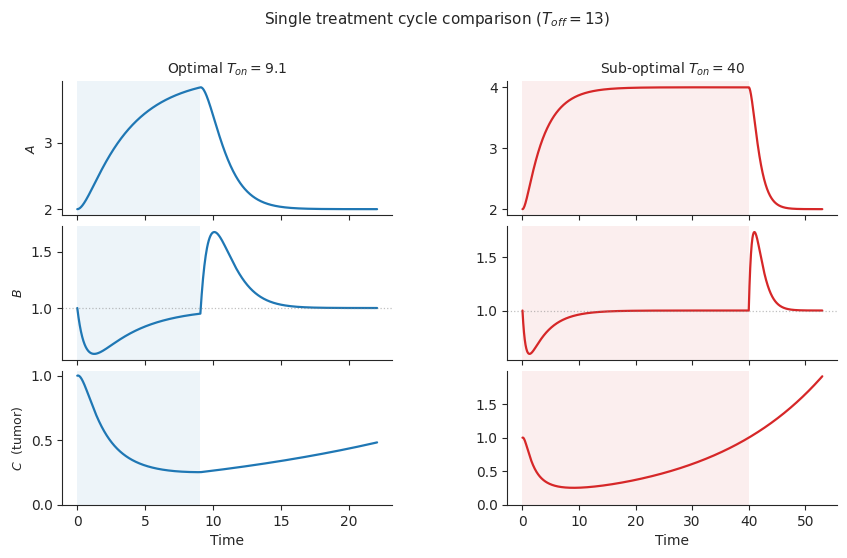

In [29]:
# ======================================================================
# Panel C': optimal vs sub-optimal Ton — single cycle, two separate plots
# ======================================================================
Ton_opt_Cp  = Ton_opt_C        # optimal from Panel C
Ton_sub_Cp  = 40.0             # sub-optimal: 'treatment too long' regime
Toff_Cp     = T_OFF            # same Toff as Panel C (=5)

_cases = [
    dict(Ton=Ton_opt_Cp, color='C0', title=rf'Optimal $T_{{on}}={Ton_opt_Cp:.1f}$'),
    dict(Ton=Ton_sub_Cp, color='C3', title=rf'Sub-optimal $T_{{on}}={Ton_sub_Cp:.0f}$'),
]

_sims = []
for _c in _cases:
    _y0 = [A_ss, B_ss, 1.0]
    _t_on  = np.linspace(0, _c['Ton'], 1200)
    _sol_on = odeint(lambda y, t: abc_rhs(t, y, b1_on), _y0, _t_on)
    _t_off  = np.linspace(0, Toff_Cp, 400)
    _sol_off = odeint(lambda y, t: abc_rhs(t, y, b1), list(_sol_on[-1]), _t_off)
    _t   = np.concatenate([_t_on, _c['Ton'] + _t_off[1:]])
    _sol = np.concatenate([_sol_on, _sol_off[1:]])
    _sims.append(dict(t=_t, A=_sol[:,0], B=_sol[:,1], C=_sol[:,2], **_c))

# ── Plot: 2 columns × 3 rows ──────────────────────────────────────────
fig_Cp, axes_Cp = plt.subplots(3, 2, figsize=(10, 5.5),
                                gridspec_kw={'hspace': 0.08, 'wspace': 0.35})

for col, _d in enumerate(_sims):
    axs = axes_Cp[:, col]
    for _ax in axs:
        _ax.axvspan(0, _d['Ton'], color=_d['color'], alpha=0.08, lw=0, zorder=0)
        clean_ax(_ax)

    axs[0].plot(_d['t'], _d['A'], color=_d['color'], lw=1.6)
    axs[1].plot(_d['t'], _d['B'], color=_d['color'], lw=1.6)
    axs[1].axhline(mu, color='gray', ls=':', lw=0.9, alpha=0.5)
    axs[2].plot(_d['t'], _d['C'], color=_d['color'], lw=1.6)

    axs[2].set_xlabel('Time', fontsize=10)
    axs[2].set_ylim(bottom=0)
    axs[0].tick_params(labelbottom=False)
    axs[1].tick_params(labelbottom=False)
    axs[0].set_title(_d['title'], fontsize=10)

# y-labels on left column only
axes_Cp[0, 0].set_ylabel('$A$', fontsize=9)
axes_Cp[1, 0].set_ylabel('$B$', fontsize=9)
axes_Cp[2, 0].set_ylabel('$C$  (tumor)', fontsize=9)

fig_Cp.suptitle(rf'Single treatment cycle comparison ($T_{{off}}={Toff_Cp:.0f}$)',
                fontsize=11, y=1.01)

plt.tight_layout()
plt.show()


**Panel D** — Multi-cycle adaptive therapy using the optimal $T_{on}$ from Panel C.

/tmp/ipykernel_2807486/1948679447.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


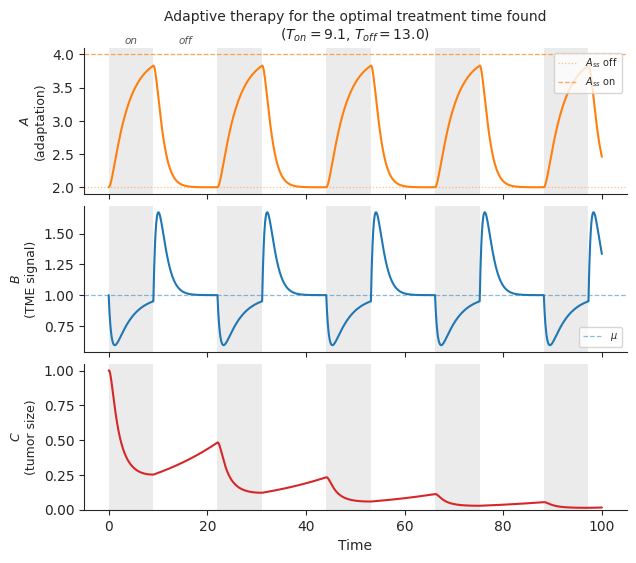

In [30]:
# ======================================================================
# Panel D: multi-cycle simulation with Ton from Panel C
# ======================================================================

T_horizon = 100.0
Ton_D  = Ton_opt_C
Toff_D = T_OFF

t_all, A_all, B_all, C_all = [], [], [], []
on_spans = []
y_cur = [A_ss, B_ss, 1.0]
t_cur = 0.0

while t_cur < T_horizon:
    # ON phase
    t_on = min(Ton_D, T_horizon - t_cur)
    t_seg = np.linspace(0, t_on, 400)
    s_on = odeint(lambda y, t: abc_rhs(t, y, b1_on), y_cur, t_seg)
    on_spans.append((t_cur, t_cur + t_on))
    t_all.append(t_cur + t_seg)
    A_all.append(s_on[:, 0]); B_all.append(s_on[:, 1]); C_all.append(s_on[:, 2])
    t_cur += t_on; y_cur = s_on[-1]
    if t_cur >= T_horizon:
        break
    # OFF phase
    t_off = min(Toff_D, T_horizon - t_cur)
    t_seg = np.linspace(0, t_off, 400)
    s_off = odeint(lambda y, t: abc_rhs(t, y, b1), y_cur, t_seg)
    t_all.append(t_cur + t_seg)
    A_all.append(s_off[:, 0]); B_all.append(s_off[:, 1]); C_all.append(s_off[:, 2])
    t_cur += t_off; y_cur = s_off[-1]

t_cyc = np.concatenate(t_all)
A_cyc = np.concatenate(A_all)
B_cyc = np.concatenate(B_all)
C_cyc = np.concatenate(C_all)

# ── Plot ──────────────────────────────────────────────────────────────
fig_D, axes_D = plt.subplots(3, 1, figsize=(7, 6), sharex=True,
                              gridspec_kw={'hspace': 0.08})

for t_start, t_end in on_spans:
    for ax in axes_D:
        ax.axvspan(t_start, t_end, color='lightgray', alpha=0.45, lw=0, zorder=0)

for ax in axes_D:
    clean_ax(ax)

axes_D[0].plot(t_cyc, A_cyc, color='C1', lw=1.5)
axes_D[0].axhline(A_ss,    color='C1', ls=':',  lw=0.9, alpha=0.5, label=f'$A_{{ss}}$ off')
axes_D[0].axhline(A_ss_on, color='C1', ls='--', lw=0.9, alpha=0.7, label=f'$A_{{ss}}$ on')
axes_D[0].set_ylabel('$A$\n(adaptation)', fontsize=9)
axes_D[0].legend(fontsize=7, loc='upper right')

axes_D[1].plot(t_cyc, B_cyc, color='C0', lw=1.5)
axes_D[1].axhline(mu, color='C0', ls='--', lw=0.9, alpha=0.5, label=r'$\mu$')
axes_D[1].set_ylabel('$B$\n(TME signal)', fontsize=9)
axes_D[1].legend(fontsize=7, loc='lower right')

axes_D[2].plot(t_cyc, C_cyc, color='C3', lw=1.5)
axes_D[2].set_ylabel('$C$\n(tumor size)', fontsize=9)
axes_D[2].set_xlabel('Time', fontsize=10)
axes_D[2].set_ylim(bottom=0)

# Annotate on/off
trans = axes_D[0].get_xaxis_transform()
kw_lbl = dict(ha='center', va='bottom', fontsize=7.5, color='#555555',
              fontstyle='italic', transform=trans)
if on_spans:
    t0_on, t1_on = on_spans[0]
    axes_D[0].text((t0_on + t1_on) / 2, 1.01, 'on', **kw_lbl)
    if len(on_spans) > 1:
        t_off_start = t1_on
        t_off_end   = on_spans[1][0]
        axes_D[0].text((t_off_start + t_off_end) / 2, 1.01, 'off', **kw_lbl)

axes_D[0].set_title(
    f'Adaptive therapy for the optimal treatment time found\n'
    rf'($T_{{on}}={Ton_D:.1f}$, $T_{{off}}={Toff_D:.1f}$)',
    fontsize=10)

plt.tight_layout()
plt.show()

In [31]:
# ======================================================================
# VEGF model parameters, ODE, and integration helper
# ======================================================================
from scipy.integrate import solve_ivp as _solve_ivp

k1   = 5.0    # A1 (VEGF) production rate
k2   = 2.0    # A2 (compensatory) production rate
a1_v = 0.5    # VEGF effect on E growth
a2_v = 0.1    # compensatory signal effect on E growth
r_E  = 0.5    # endothelial cell death rate
mu_v = 0.25   # vascular scaling (E_ss = mu_v * C at steady state)
c1_v = 0.1    # tumor growth rate
c2_v = 1.0    # tumor removal rate
alpha1 = 0.01  # clearance rate of A1 (VEGF)
alpha2 = 0.01  # clearance rate of A2 (compensatory)
treatment_efficacy = 0.2  # fraction of a1_v remaining during treatment (0 = fully blocked, 1 = no effect)

C0_v = 16.0
E0_v = mu_v * C0_v   # = 4.0
A1_0 = 1.2963
A2_0 = 0.1852
y0_v = [A1_0, A2_0, E0_v, C0_v]

def vegf_rhs(t, y, a1_val):
    A1, A2, E, C = y
    deficit = mu_v * C - E
    dA1 = k1 * deficit - alpha1 * A1
    dA2 = k2 * deficit - alpha2 * A2
    dE  = E * ((a1_val * A1 + a2_v * A2) * (1 - E / (4 * mu_v * C0_v)) - r_E)
    dC  = C * (c1_v - c2_v * max(deficit, 0.0))
    return [dA1, dA2, dE, dC]

def _integrate_v(y0, T, a1_val, rtol=1e-4, atol=1e-7):
    sol = _solve_ivp(lambda t, y: vegf_rhs(t, y, a1_val),
                     (0, T), y0, method='RK45', rtol=rtol, atol=atol)
    result = list(sol.y[:, -1])
    return result if all(np.isfinite(v) for v in result) else None

print(f"VEGF IC: A1={A1_0:.4f}, A2={A2_0:.4f}, E={E0_v:.2f}, C={C0_v:.2f}")
print(f"Deficit at t=0: {mu_v*C0_v - E0_v:.4f}  (should be ~0)")
print(f"Treatment: a1_v * treatment_efficacy = {a1_v * treatment_efficacy:.4f}  (vs full {a1_v})")


VEGF IC: A1=1.2963, A2=0.1852, E=4.00, C=16.00
Deficit at t=0: 0.0000  (should be ~0)
Treatment: a1_v * treatment_efficacy = 0.1000  (vs full 0.5)


**Panel E** — VEGF model: equations and biological roles.

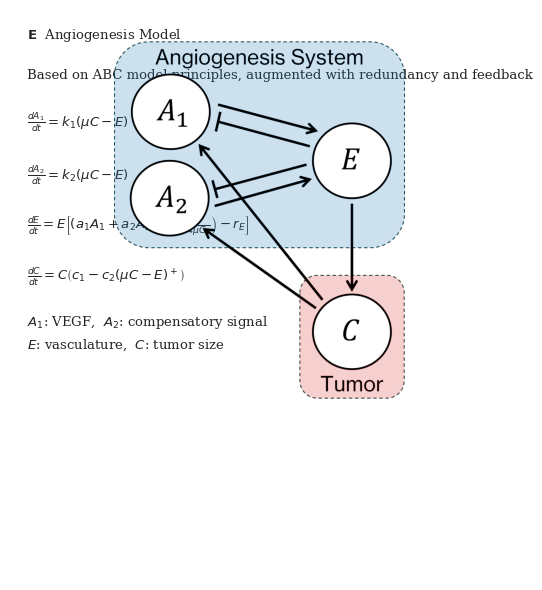

In [32]:
# Panel E: standalone — VEGF model ODEs + image
import os

fig_E, ax_E = plt.subplots(figsize=(5, 6))
ax_E.axis('off')

lines_E = [
    r'$\mathbf{E}$  Angiogenesis Model',
    '',
    r'Based on ABC model principles, augmented with redundancy and feedback',
    '',
    r'$\frac{dA_1}{dt} = k_1(\mu C - E)$',
    '',
    r'$\frac{dA_2}{dt} = k_2(\mu C - E)$',
    '',
    r'$\frac{dE}{dt} = E\left[(a_1 A_1 + a_2 A_2)\left(1-\frac{E}{4\mu C_0}\right) - r_E\right]$',
    '',
    r'$\frac{dC}{dt} = C\left(c_1 - c_2(\mu C - E)^+\right)$',
    '',
    r'$A_1$: VEGF,  $A_2$: compensatory signal',
    r'$E$: vasculature,  $C$: tumor size',
]
ax_E.text(0.05, 0.97, '\n'.join(lines_E), transform=ax_E.transAxes,
          fontsize=9.5, va='top', family='serif', linespacing=1.6)

VEGF_IMG = 'vegf_model.png'
if os.path.exists(VEGF_IMG):
    # move to the right a bit
    ax_eimg = ax_E.inset_axes([0.25, 0.3, 1.0, 0.65])
    ax_eimg.imshow(plt.imread(VEGF_IMG))
    ax_eimg.axis('off')

plt.tight_layout()
plt.show()


**Panel F** — VEGF model: growth vs. decay for fixed $T_{off}$, with three regimes.

/tmp/ipykernel_2807486/2220329623.py:20: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  decay_v_arr[_i] = c2_v * np.trapz(_deficit, _t_full)


T_off_v = 5.0
Crossings: ['0.95', '13.50']
Optimal Ton (max net decay): 3.93


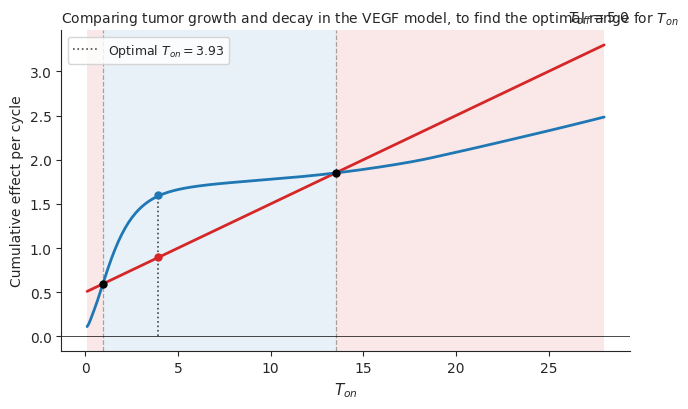


Using Ton_opt_v = 3.93 for Panel G


In [39]:
# ======================================================================
# Panel F: VEGF growth vs. decay with regime annotations
# ======================================================================

T_OFF_V    = 5.0
Ton_scan_v = np.linspace(0.1, 28, 300)

growth_v_arr = c1_v * (Ton_scan_v + T_OFF_V)

# Direct integral: c2 * trapz( (mu*C - E)+, t ) over full cycle
decay_v_arr = np.empty_like(Ton_scan_v)
for _i, _ton in enumerate(Ton_scan_v):
    _t_on  = np.linspace(0, _ton, max(int(_ton * 50), 200))
    _s_on  = odeint(lambda y, t: vegf_rhs(t, y, a1_v * treatment_efficacy), list(y0_v), _t_on)
    _t_off = np.linspace(0, T_OFF_V, 300)
    _s_off = odeint(lambda y, t: vegf_rhs(t, y, a1_v), list(_s_on[-1]), _t_off)
    _t_full   = np.concatenate([_t_on, _ton + _t_off[1:]])
    _sol_full = np.concatenate([_s_on, _s_off[1:]])
    _deficit  = np.maximum(mu_v * _sol_full[:,3] - _sol_full[:,2], 0.0)
    decay_v_arr[_i] = c2_v * np.trapz(_deficit, _t_full)

# Crossings via visual interpolation on sign changes
_net_v    = decay_v_arr - growth_v_arr
_sign_chg = np.where(np.diff(np.sign(_net_v)))[0]
crossings_v = []
for _idx in _sign_chg:
    _ta, _tb = Ton_scan_v[_idx], Ton_scan_v[_idx + 1]
    _frac = -_net_v[_idx] / (_net_v[_idx + 1] - _net_v[_idx])
    crossings_v.append(_ta + _frac * (_tb - _ta))

Ton_opt_v = Ton_scan_v[np.nanargmax(_net_v)]
print(f'T_off_v = {T_OFF_V}')
print(f'Crossings: {[f"{c:.2f}" for c in crossings_v]}')
print(f'Optimal Ton (max net decay): {Ton_opt_v:.2f}')

# ── Plot ──────────────────────────────────────────────────────────────
fig_F, ax_F = plt.subplots(figsize=(6.5, 4.2))

_xmax_v       = Ton_scan_v[-1]
_regime_alpha = 0.10
if len(crossings_v) >= 2:
    _cv1, _cv2 = crossings_v[0], crossings_v[1]
    ax_F.axvspan(Ton_scan_v[0], _cv1,    color='C3', alpha=_regime_alpha, lw=0)
    ax_F.axvspan(_cv1,          _cv2,    color='C0', alpha=_regime_alpha, lw=0)
    ax_F.axvspan(_cv2,          _xmax_v, color='C3', alpha=_regime_alpha, lw=0)
    for _cx in (_cv1, _cv2):
        ax_F.axvline(_cx, color='gray', ls='--', lw=0.9, alpha=0.7)
elif len(crossings_v) == 1:
    _cv1 = crossings_v[0]
    ax_F.axvspan(Ton_scan_v[0], _cv1,    color='C3', alpha=_regime_alpha, lw=0)
    ax_F.axvspan(_cv1,          _xmax_v, color='C0', alpha=_regime_alpha, lw=0)
    ax_F.axvline(_cv1, color='gray', ls='--', lw=0.9, alpha=0.7)

_nudge_F = ScaledTranslation(0, 0.5/72, fig_F.dpi_scale_trans)
_trans_F = lambda ax: ax.transData + _nudge_F

ax_F.plot(Ton_scan_v, growth_v_arr, color='C3', lw=2)
ax_F.plot(Ton_scan_v, decay_v_arr,  color='C0', lw=2)
ax_F.axhline(0, color='k', lw=0.5)

# Crossing dots
if len(crossings_v) >= 1:
    for _cx in crossings_v:
        _val = c1_v * (_cx + T_OFF_V)
        ax_F.plot(_cx, _val, 'o', color='k', ms=5, zorder=5)

# Optimal Ton line + dots
_y_grow_opt_v = c1_v * (Ton_opt_v + T_OFF_V)
_y_dec_opt_v  = decay_v_arr[np.argmax(_net_v)]
_y_top_opt_v  = max(_y_grow_opt_v, _y_dec_opt_v)

ax_F.plot([Ton_opt_v, Ton_opt_v], [0, _y_top_opt_v],
          color='k', ls=':', lw=1.2, alpha=0.7, label=rf'Optimal $T_{{on}} = ${Ton_opt_v:.2f}')
ax_F.plot(Ton_opt_v, _y_grow_opt_v, 'o', color='C3', ms=6, zorder=7, mec='none',
          transform=_trans_F(ax_F))
ax_F.plot(Ton_opt_v, _y_dec_opt_v,  'o', color='C0', ms=6, zorder=7, mec='none',
          transform=_trans_F(ax_F))


ax_F.set_xlabel(r'$T_{on}$', fontsize=11)
ax_F.set_ylabel('Cumulative effect per cycle', fontsize=10)
ax_F.set_title(r'Comparing tumor growth and decay in the VEGF model,'
               r' to find the optimal range for $T_{on}$', fontsize=10, loc='left')
ax_F.set_title(rf'$T_{{off}} = {T_OFF_V}$', fontsize=10, loc='right')
ax_F.legend(fontsize=9, loc='upper left')
clean_ax(ax_F)
plt.tight_layout()
plt.show()

print(f'\nUsing Ton_opt_v = {Ton_opt_v:.2f} for Panel G')


<>:86: SyntaxWarning: invalid escape sequence '\,'
<>:86: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_2807486/170096423.py:86: SyntaxWarning: invalid escape sequence '\,'
  axes_Fd[0, 0].set_ylabel('$A_1,\,A_2$',   fontsize=9)
/tmp/ipykernel_2807486/170096423.py:33: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  _decay_direct = c2_v * np.trapz(_deficit_full, _t)
/tmp/ipykernel_2807486/170096423.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


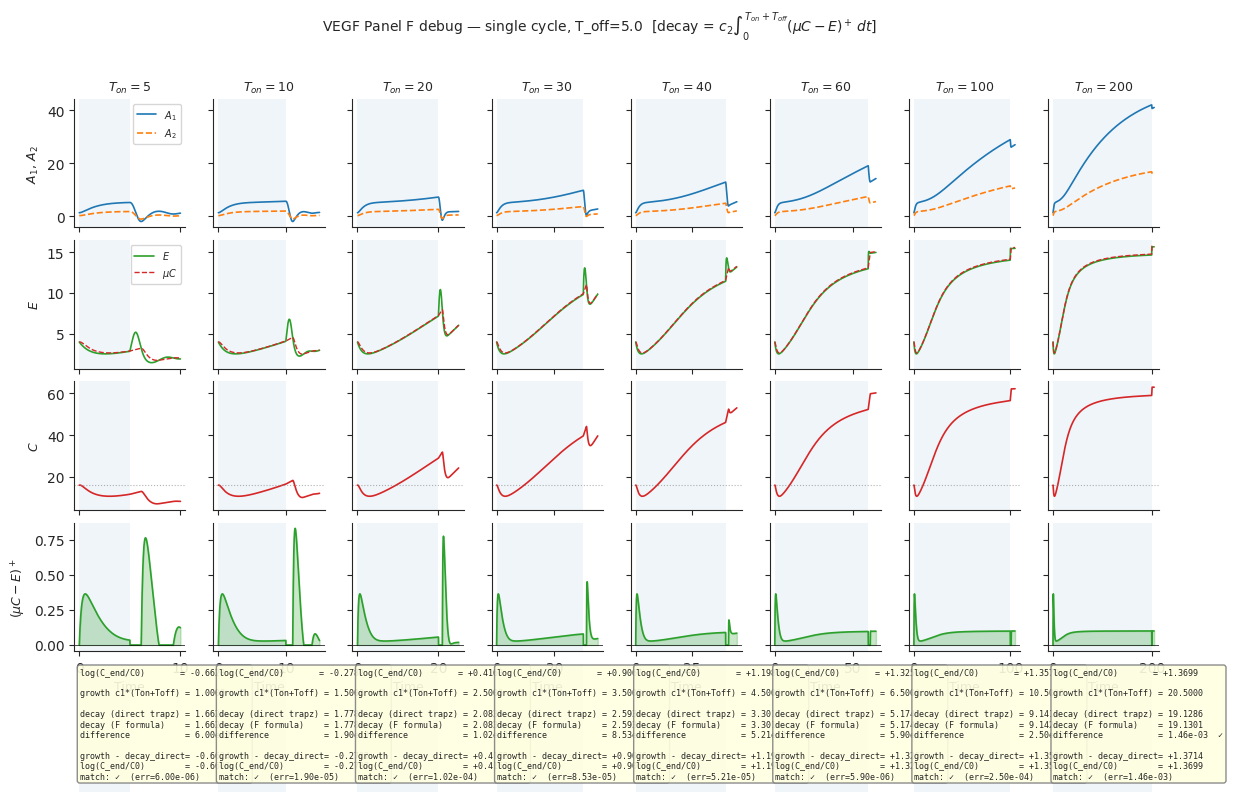

In [40]:
# ======================================================================
# Panel F debug: single-cycle simulation + direct integral verification
# ======================================================================
_Ton_debug = [5.0, 10.0, 20.0, 30.0, 40.0, 60.0, 100.0, 200.0]
_T_off_d   = T_OFF_V

fig_Fd, axes_Fd = plt.subplots(5, len(_Ton_debug), figsize=(14, 9),
                                sharex='col', sharey='row',
                                gridspec_kw={'hspace': 0.10, 'wspace': 0.25})

for col, _ton in enumerate(_Ton_debug):
    # ── Simulate one full cycle ───────────────────────────────────────
    _t_on   = np.linspace(0, _ton, 2000)
    _sol_on = odeint(lambda y, t: vegf_rhs(t, y, a1_v * treatment_efficacy), list(y0_v), _t_on)
    _t_off  = np.linspace(0, _T_off_d, 600)
    _sol_off = odeint(lambda y, t: vegf_rhs(t, y, a1_v), list(_sol_on[-1]), _t_off)

    _t   = np.concatenate([_t_on, _ton + _t_off[1:]])
    _sol = np.concatenate([_sol_on, _sol_off[1:]])
    _A1, _A2, _E, _C = _sol[:,0], _sol[:,1], _sol[:,2], _sol[:,3]

    # ── Direct computations ───────────────────────────────────────────
    # Deficit over FULL cycle (ON + OFF)
    _deficit_full = np.maximum(mu_v * _C - _E, 0.0)

    # 1. Actual log-fold change from simulation
    _logfold_actual = np.log(_C[-1] / y0_v[3])

    # 2. Direct growth: c1 * (Ton + Toff)
    _growth_direct = c1_v * (_ton + _T_off_d)

    # 3. Direct decay: c2 * integral over FULL cycle
    _decay_direct = c2_v * np.trapz(_deficit_full, _t)

    # 4. Formula-based decay (as in Panel F): growth - log(C_end/C0)
    _decay_formula = _growth_direct - _logfold_actual

    # 5. Check: growth - decay_direct should equal log-fold
    _check = _growth_direct - _decay_direct

    # ── Plot ─────────────────────────────────────────────────────────
    axs = axes_Fd[:, col]
    for _ax in axs:
        _ax.axvspan(0, _ton, color='steelblue', alpha=0.08, lw=0, zorder=0)
        clean_ax(_ax)

    axs[0].plot(_t, _A1, color='C0', lw=1.2, label='$A_1$')
    axs[0].plot(_t, _A2, color='C1', lw=1.2, ls='--', label='$A_2$')
    axs[1].plot(_t, _E,      color='C2', lw=1.2, label='$E$')
    axs[1].plot(_t, mu_v*_C, color='C3', lw=1.0, ls='--', label=r'$\mu C$')
    axs[2].plot(_t, _C, color='C3', lw=1.2)
    axs[2].axhline(y0_v[3], color='gray', ls=':', lw=0.8, alpha=0.6)

    # Row 3: deficit over full cycle, shaded
    axs[3].plot(_t, _deficit_full, color='C2', lw=1.2)
    axs[3].fill_between(_t, _deficit_full, alpha=0.25, color='C2')
    axs[3].axhline(0, color='k', lw=0.5)

    # Row 4: verification
    axs[4].axis('off')
    _err = abs(_decay_direct - _decay_formula)
    _lines = [
        f'log(C_end/C0)       = {_logfold_actual:+.4f}',
        '',
        f'growth c1*(Ton+Toff) = {_growth_direct:.4f}',
        '',
        f'decay (direct trapz) = {_decay_direct:.4f}',
        f'decay (F formula)    = {_decay_formula:.4f}',
        f'difference           = {_err:.2e}  {"✓" if _err < 1e-2 else "✗"}',
        '',
        f'growth - decay_direct= {_check:+.4f}',
        f'log(C_end/C0)        = {_logfold_actual:+.4f}',
        f'match: {"✓" if abs(_check-_logfold_actual)<1e-2 else "✗"}  (err={abs(_check-_logfold_actual):.2e})',
    ]
    axs[4].text(0.05, 0.97, '\n'.join(_lines), transform=axs[4].transAxes,
                ha='left', va='top', fontsize=6, family='monospace',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                          edgecolor='gray', alpha=0.9))

    axs[0].set_title(rf'$T_{{on}}={_ton:.0f}$', fontsize=9)
    for _ax in axs[:4]:
        _ax.tick_params(labelbottom=False)
    axs[3].tick_params(labelbottom=True)
    axs[3].set_xlabel('Time', fontsize=9)

axes_Fd[0, 0].set_ylabel('$A_1,\,A_2$',   fontsize=9)
axes_Fd[1, 0].set_ylabel('$E$',            fontsize=9)
axes_Fd[2, 0].set_ylabel('$C$',            fontsize=9)
axes_Fd[3, 0].set_ylabel(r'$(\mu C-E)^+$', fontsize=9)
axes_Fd[0, 0].legend(fontsize=7, loc='upper right')
axes_Fd[1, 0].legend(fontsize=7, loc='upper right')

fig_Fd.suptitle(f'VEGF Panel F debug — single cycle, T_off={_T_off_d}  '
                r'[decay = $c_2\int_0^{T_{on}+T_{off}}(\mu C-E)^+\,dt$]',
                fontsize=10)
plt.tight_layout()
plt.show()


**Panel G** — VEGF adaptive therapy using the optimal $T_{on}$ from Panel F.

<>:51: SyntaxWarning: invalid escape sequence '\,'
<>:51: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_2807486/3319101384.py:51: SyntaxWarning: invalid escape sequence '\,'
  axes_G[0].set_ylabel('$A_1,\,A_2$', fontsize=9)
/tmp/ipykernel_2807486/3319101384.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


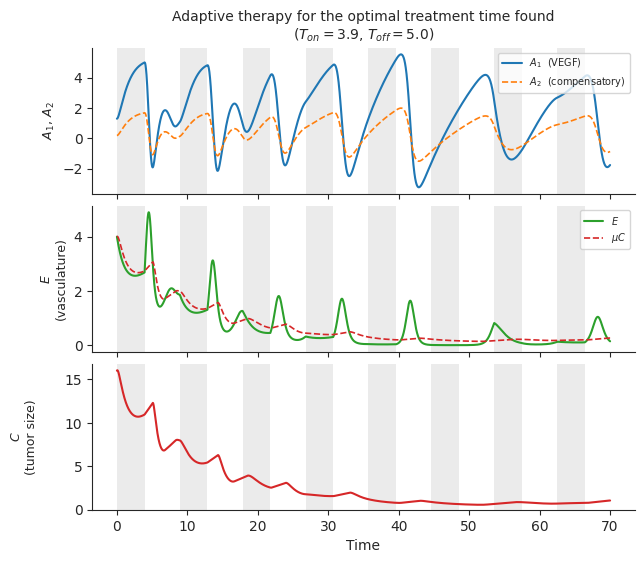

In [41]:
# ======================================================================
# Panel G: VEGF adaptive therapy simulation
# ======================================================================
T_horizon_v = 70.0
Ton_G  = Ton_opt_v
Toff_G = T_OFF_V

t_all_v, _A1_all, _A2_all, _E_all, _C_all_v = [], [], [], [], []
on_spans_v = []
y_cur_v = list(y0_v)
t_cur   = 0.0

while t_cur < T_horizon_v:
    # ON phase (a1 reduced by treatment_efficacy)
    _t_on  = min(Ton_G, T_horizon_v - t_cur)
    _t_seg = np.linspace(0, _t_on, 400)
    _sol   = odeint(lambda y, t: vegf_rhs(t, y, a1_v * treatment_efficacy), y_cur_v, _t_seg)
    on_spans_v.append((t_cur, t_cur + _t_on))
    t_all_v.append(t_cur + _t_seg)
    _A1_all.append(_sol[:, 0]); _A2_all.append(_sol[:, 1])
    _E_all.append(_sol[:, 2]); _C_all_v.append(_sol[:, 3])
    t_cur += _t_on; y_cur_v = list(_sol[-1])
    if t_cur >= T_horizon_v: break
    # OFF phase
    _t_off = min(Toff_G, T_horizon_v - t_cur)
    _t_seg = np.linspace(0, _t_off, 400)
    _sol   = odeint(lambda y, t: vegf_rhs(t, y, a1_v), y_cur_v, _t_seg)
    t_all_v.append(t_cur + _t_seg)
    _A1_all.append(_sol[:, 0]); _A2_all.append(_sol[:, 1])
    _E_all.append(_sol[:, 2]); _C_all_v.append(_sol[:, 3])
    t_cur += _t_off; y_cur_v = list(_sol[-1])

t_vv  = np.concatenate(t_all_v)
A1_vv = np.concatenate(_A1_all)
A2_vv = np.concatenate(_A2_all)
E_vv  = np.concatenate(_E_all)
C_vv  = np.concatenate(_C_all_v)

fig_G, axes_G = plt.subplots(3, 1, figsize=(7, 6), sharex=True,
                              gridspec_kw={'hspace': 0.08})

for _ts, _te in on_spans_v:
    for ax in axes_G:
        ax.axvspan(_ts, _te, color='lightgray', alpha=0.45, lw=0, zorder=0)

for ax in axes_G:
    clean_ax(ax)

axes_G[0].plot(t_vv, A1_vv, color='C0', lw=1.5, label='$A_1$  (VEGF)')
axes_G[0].plot(t_vv, A2_vv, color='C1', lw=1.2, ls='--', label='$A_2$  (compensatory)')
axes_G[0].set_ylabel('$A_1,\,A_2$', fontsize=9)
axes_G[0].legend(fontsize=7, loc='upper right')

axes_G[1].plot(t_vv, E_vv,           color='C2', lw=1.5, label='$E$')
axes_G[1].plot(t_vv, mu_v * C_vv,    color='C3', lw=1.2, ls='--', label=r'$\mu C$')
axes_G[1].set_ylabel('$E$\n(vasculature)', fontsize=9)
axes_G[1].legend(fontsize=7, loc='upper right')

axes_G[2].plot(t_vv, C_vv, color='C3', lw=1.5)
axes_G[2].set_ylabel('$C$\n(tumor size)', fontsize=9)
axes_G[2].yaxis.set_label_coords(-0.10, 0.5)
axes_G[2].set_xlabel('Time', fontsize=10)
axes_G[2].set_ylim(bottom=0)

axes_G[0].set_title(
    f'Adaptive therapy for the optimal treatment time found\n'
    rf'($T_{{on}}={Ton_G:.1f}$, $T_{{off}}={Toff_G:.1f}$)',
    fontsize=10)

plt.tight_layout()
plt.show()


/tmp/ipykernel_2807486/2321826417.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


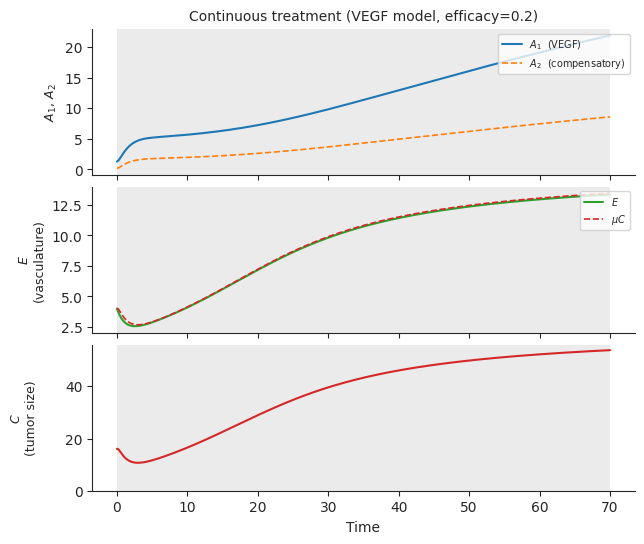

In [42]:
# ======================================================================
# Panel H: VEGF continuous treatment simulation
# ======================================================================
T_horizon_H = 70.0

_t_H   = np.linspace(0, T_horizon_H, 3000)
_sol_H = odeint(lambda y, t: vegf_rhs(t, y, a1_v * treatment_efficacy), list(y0_v), _t_H)
A1_H, A2_H, E_H, C_H = _sol_H[:,0], _sol_H[:,1], _sol_H[:,2], _sol_H[:,3]

fig_H, axes_H = plt.subplots(3, 1, figsize=(7, 6), sharex=True,
                              gridspec_kw={'hspace': 0.08})
for ax in axes_H:
    ax.axvspan(0, T_horizon_H, color='lightgray', alpha=0.45, lw=0, zorder=0)
    clean_ax(ax)

axes_H[0].plot(_t_H, A1_H, color='C0', lw=1.5, label=r'$A_1$  (VEGF)')
axes_H[0].plot(_t_H, A2_H, color='C1', lw=1.2, ls='--', label=r'$A_2$  (compensatory)')
axes_H[0].set_ylabel(r'$A_1,\,A_2$', fontsize=9)
axes_H[0].legend(fontsize=7, loc='upper right')

axes_H[1].plot(_t_H, E_H,          color='C2', lw=1.5, label=r'$E$')
axes_H[1].plot(_t_H, mu_v * C_H,   color='C3', lw=1.2, ls='--', label=r'$\mu C$')
axes_H[1].set_ylabel('$E$\n(vasculature)', fontsize=9)
axes_H[1].legend(fontsize=7, loc='upper right')

axes_H[2].plot(_t_H, C_H, color='C3', lw=1.5)
axes_H[2].set_ylabel('$C$\n(tumor size)', fontsize=9)
axes_H[2].yaxis.set_label_coords(-0.10, 0.5)
axes_H[2].set_xlabel('Time', fontsize=10)
axes_H[2].set_ylim(bottom=0)

axes_H[0].set_title(f'Continuous treatment (VEGF model, efficacy={treatment_efficacy})', fontsize=10)
plt.tight_layout()
plt.show()


κ₁=40.0, κ₂=3.2, γ₂=8.00
IC: x1=1.2963, x2=0.0370, e=1.0000, c=1.0
Computing heatmaps (γ₁ = 0.5, 1.3)...
  γ₁=0.2: 0 NaNs / 900


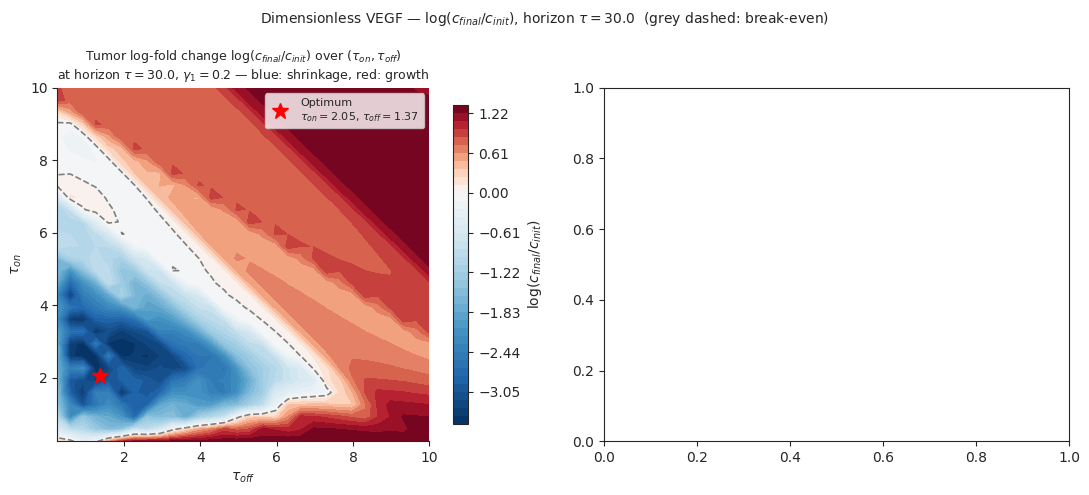

In [48]:
# ======================================================================
# Panels I & J: dimensionless VEGF heatmaps for gamma1 = 0.5 and 1.3
# ======================================================================
from scipy.integrate import solve_ivp as _siv_dl
from scipy.optimize import minimize as _minimize_dl
from matplotlib.colors import TwoSlopeNorm, Normalize

# ── Dimensionless parameters (derived from dimensional ones in cell 12) ──
_kappa1 = k1  * a1_v * mu_v * C0_v / r_E**2   # = 40.0
_kappa2 = k2  * a2_v * mu_v * C0_v / r_E**2   # = 8.0
_gamma2 = c2_v * mu_v * C0_v / r_E

_x1_0  = A1_0 * a1_v / r_E
_x2_0  = A2_0 * a2_v / r_E
_e_0   = E0_v / (mu_v * C0_v)
_y0_dl = [_x1_0, _x2_0, _e_0, 1.0]

print(f"κ₁={_kappa1:.1f}, κ₂={_kappa2:.1f}, γ₂={_gamma2:.2f}")
print(f"IC: x1={_x1_0:.4f}, x2={_x2_0:.4f}, e={_e_0:.4f}, c=1.0")

_T_horizon_dl  = 30.0
_tau_on_grid   = np.linspace(0.25, 10, 30)
_tau_off_grid  = np.linspace(0.25, 10, 30)

def _vegf_dl_rhs(tau, y, treated, gamma1_val):
    x1, x2, e, c = y
    deficit = c - e
    signal  = (treatment_efficacy * x1 if treated else x1) + x2
    return [
        _kappa1 * deficit,
        _kappa2 * deficit,
        e * (signal * (1 - e / 4) - 1),
        c * (gamma1_val - _gamma2 * max(deficit, 0)),
    ]

def _integ_dl(y0, T, treated, gamma1_val):
    sol = _siv_dl(lambda tau, y: _vegf_dl_rhs(tau, y, treated, gamma1_val),
                  (0, T), y0, method='RK45', rtol=1e-4, atol=1e-7)
    res = list(sol.y[:, -1])
    return res if all(np.isfinite(v) for v in res) else None

def _J_dl(tau_on, tau_off, gamma1_val):
    y_cur  = list(_y0_dl)
    c_init = y_cur[3]
    t_el   = 0.0
    while t_el < _T_horizon_dl:
        t_on  = min(tau_on, _T_horizon_dl - t_el)
        y_cur = _integ_dl(y_cur, t_on, True, gamma1_val)
        if y_cur is None: return np.nan
        t_el += t_on
        if t_el >= _T_horizon_dl: break
        t_off = min(tau_off, _T_horizon_dl - t_el)
        y_cur = _integ_dl(y_cur, t_off, False, gamma1_val)
        if y_cur is None: return np.nan
        t_el += t_off
    val = np.log(y_cur[3] / c_init)
    return val if np.isfinite(val) else np.nan

def _plot_heatmap_dl(ax, fig_ref, gamma1_val):
    J_grid = np.array([[_J_dl(ton, toff, gamma1_val)
                        for toff in _tau_off_grid]
                       for ton  in _tau_on_grid])
    n_nan = np.sum(~np.isfinite(J_grid))
    print(f"  γ₁={gamma1_val}: {n_nan} NaNs / {J_grid.size}")

    # Optimal via grid + refinement
    best = np.unravel_index(np.nanargmin(J_grid), J_grid.shape)
    res  = _minimize_dl(
        lambda x: _J_dl(x[0], x[1], gamma1_val),
        x0=[_tau_on_grid[best[0]], _tau_off_grid[best[1]]],
        bounds=[(0.1, 15), (0.1, 15)], method='L-BFGS-B'
    )
    tau_on_opt, tau_off_opt = res.x

    J_m = np.ma.masked_invalid(J_grid)
    vmin, vmax = float(np.nanmin(J_grid)), float(np.nanmax(J_grid))
    if vmin < 0 < vmax:
        norm   = TwoSlopeNorm(vcenter=0.0, vmin=vmin, vmax=vmax)
        levels = np.linspace(vmin, vmax, 41)
    elif vmin >= 0:
        norm   = Normalize(vmin=-vmax, vmax=vmax)
        levels = np.linspace(0.0, vmax, 41)
    else:
        norm   = Normalize(vmin=vmin, vmax=-vmin)
        levels = np.linspace(vmin, 0.0, 41)

    im = ax.contourf(_tau_off_grid, _tau_on_grid, J_m, levels=levels, cmap='RdBu_r', norm=norm)
    fig_ref.colorbar(im, ax=ax, label=r'$\log(c_{final}/c_{init})$', shrink=0.9)
    if vmin < 0 < vmax:
        ax.contour(_tau_off_grid, _tau_on_grid, J_m,
                   levels=[0], colors='grey', linewidths=1.2, linestyles='--')
    ax.plot(tau_off_opt, tau_on_opt, 'r*', ms=12,
            label=f'Optimum\n$\\tau_{{on}}={tau_on_opt:.2f}$, $\\tau_{{off}}={tau_off_opt:.2f}$')
    ax.set_xlabel(r'$\tau_{off}$', fontsize=10)
    ax.set_ylabel(r'$\tau_{on}$',  fontsize=10)
    ax.set_title(
        rf'Tumor log-fold change $\log(c_{{final}}/c_{{init}})$ over $(\tau_{{on}}, \tau_{{off}})$'
        + '\n' +
        rf'at horizon $\tau={_T_horizon_dl}$, $\gamma_1={gamma1_val}$ — blue: shrinkage, red: growth',
        fontsize=9)
    ax.legend(fontsize=8, loc='upper right')
    clean_ax(ax)

fig_IJ, (ax_I, ax_J) = plt.subplots(1, 2, figsize=(11, 5))
fig_IJ.suptitle(
    rf'Dimensionless VEGF — $\log(c_{{final}}/c_{{init}})$, horizon $\tau={_T_horizon_dl}$'
    '  (grey dashed: break-even)',
    fontsize=10)
print("Computing heatmaps (γ₁ = 0.5, 1.3)...")
_plot_heatmap_dl(ax_I, fig_IJ, 0.2)
# _plot_heatmap_dl(ax_J, fig_IJ, 0.8)
plt.tight_layout()
plt.show()


## Composite Figure 4

<>:355: SyntaxWarning: invalid escape sequence '\,'
<>:391: SyntaxWarning: invalid escape sequence '\,'
<>:355: SyntaxWarning: invalid escape sequence '\,'
<>:391: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_2807486/76675055.py:355: SyntaxWarning: invalid escape sequence '\,'
  axG0.set_ylabel('$A_1,\,A_2$', fontsize=9)
/tmp/ipykernel_2807486/76675055.py:391: SyntaxWarning: invalid escape sequence '\,'
  axH0.set_ylabel('$A_1,\,A_2$', fontsize=9)
/tmp/ipykernel_2807486/76675055.py:283: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  _dec_v[_i] = c2_v * np.trapz(_deficit, _t_full)


Computing composite heatmaps...


/tmp/ipykernel_2807486/76675055.py:490: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


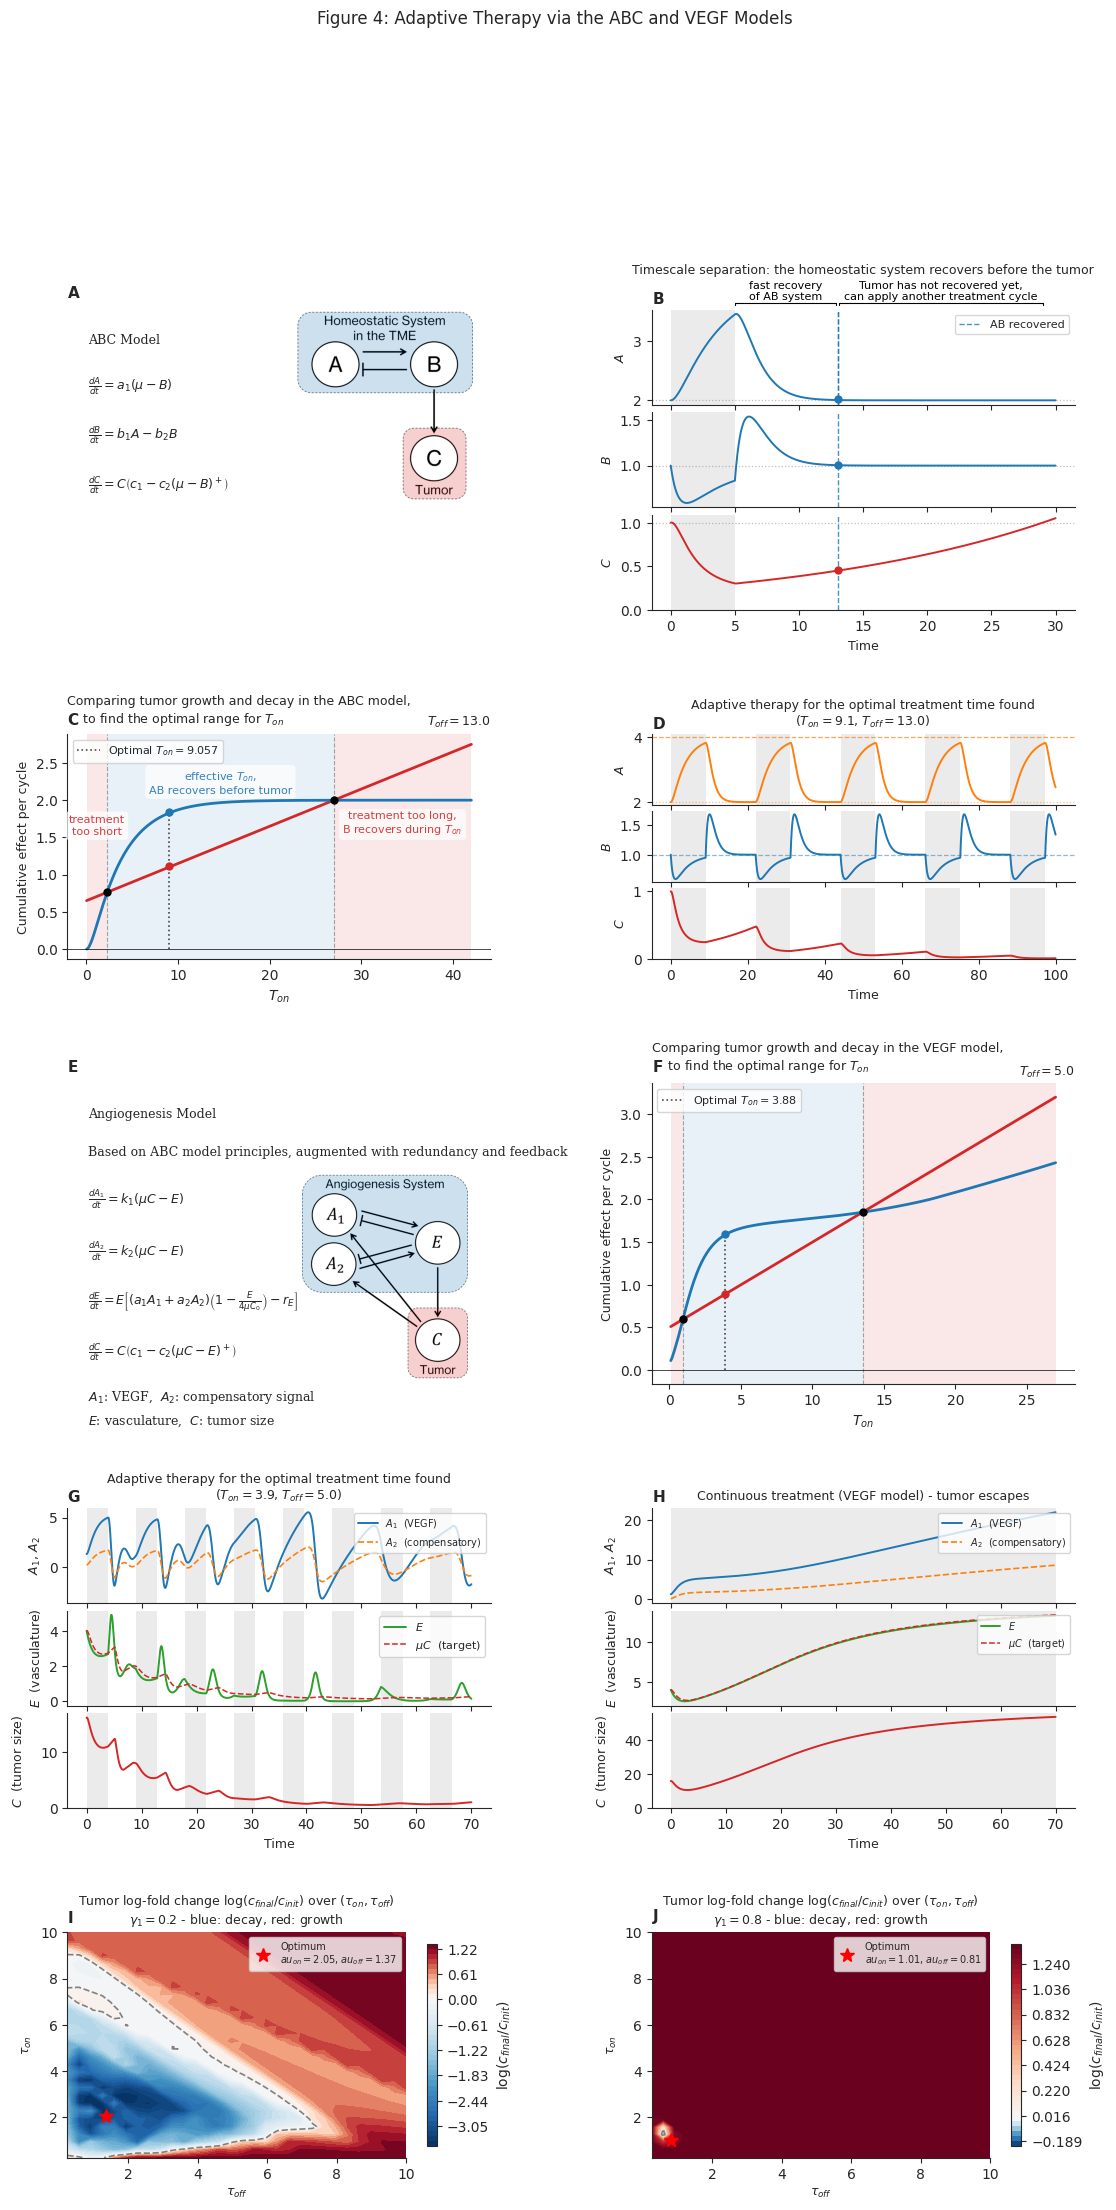

In [49]:
# ======================================================================
# COMPOSITE FIGURE  —  2-column, 4-row layout
#   Row 0: A (col 0) | B (col 1)
#   Row 1: C (col 0) | D 3-subplots (col 1)
#   Row 2: E (col 0) | F (col 1)
#   Row 3: G 3-subplots (spans both columns)
# ======================================================================
import os
from scipy.optimize import brentq

LETTER_KW = dict(fontsize=11, fontweight='bold', va='bottom', ha='left')
TITLE_KW  = dict(fontsize=9,  va='top', family='serif', linespacing=1.6)

def label_panel(ax, letter, x=0.0, y=1.03):
    ax.text(x, y, rf'$\mathbf{{{letter}}}$', transform=ax.transAxes, **LETTER_KW)

fig = plt.figure(figsize=(13, 24))
gs = gridspec.GridSpec(9, 2, figure=fig,
                       hspace=0.38, wspace=0.38,
                       height_ratios=[2.0, 0.05, 1.5, 0.05, 2.0, 0.05, 2.0, 0.05, 1.5])
# Row 0: A, B  |  Row 1: spacer  |  Row 2: C, D  |  Row 3: spacer
# Row 4: E, F  |  Row 5: spacer  |  Row 6: G, H  |  Row 7: spacer  |  Row 8: I, J

_nudge = ScaledTranslation(0, 0.5/72, fig.dpi_scale_trans)
_trans = lambda ax: ax.transData + _nudge
# ── Panel A ──────────────────────────────────────────────────────────
ax_A = fig.add_subplot(gs[0, 0])
ax_A.axis('off')
label_panel(ax_A, 'A')
lines_A = [
    r'ABC Model',
    '',
    r'$\frac{dA}{dt} = a_1(\mu - B)$',
    '',
    r'$\frac{dB}{dt} = b_1 A - b_2 B$',
    '',
    r'$\frac{dC}{dt} = C\left(c_1 - c_2(\mu-B)^+\right)$',
]
ax_A.text(0.05, 0.92, '\n'.join(lines_A), transform=ax_A.transAxes, **TITLE_KW)
ABC_IMG = 'abc_model.png'
if os.path.exists(ABC_IMG):
    ax_Aimg = ax_A.inset_axes([0.25, 0.35, 1.0, 0.65])
    ax_Aimg.imshow(plt.imread(ABC_IMG))
    ax_Aimg.axis('off')

# ── Panel B ──────────────────────────────────────────────────────────
gs_B = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=gs[0, 1], hspace=0.08)
axB0 = fig.add_subplot(gs_B[0])
axB1 = fig.add_subplot(gs_B[1], sharex=axB0)
axB2 = fig.add_subplot(gs_B[2], sharex=axB0)
label_panel(axB0, 'B')

_Ton_B = 5.0; _Toff_B = 25.0; _C0_B = 1.0; epsilon = 0.1
_y0_B  = [A_ss, B_ss, _C0_B]
_t_on_B  = np.linspace(0, _Ton_B, 2000)
_sol_on_B  = odeint(lambda y, t: abc_rhs(t, y, b1_on), _y0_B, _t_on_B)
_t_off_B = np.linspace(0, _Toff_B, 2000)
_sol_off_B = odeint(lambda y, t: abc_rhs(t, y, b1), list(_sol_on_B[-1]), _t_off_B)
_t_B = np.concatenate([_t_on_B, _Ton_B + _t_off_B[1:]])
_A_B = np.concatenate([_sol_on_B[:, 0], _sol_off_B[1:, 0]])
_B_B = np.concatenate([_sol_on_B[:, 1], _sol_off_B[1:, 1]])
_C_B = np.concatenate([_sol_on_B[:, 2], _sol_off_B[1:, 2]])
_imin_B = _C_B.argmin()
_t_after_B = _t_B[_imin_B:]; _C_after_B = _C_B[_imin_B:]
_sc_B = np.where(np.diff(np.sign(_C_after_B - _C0_B)) > 0)[0]
_t_C_rec_B = brentq(lambda t: np.interp(t, _t_B, _C_B) - _C0_B,
                    _t_after_B[_sc_B[0]], _t_after_B[_sc_B[0]+1])
_t_AB_mark_B = 13.0
_epsilon_B = 0.1

for _ax in [axB0, axB1, axB2]:
    _ax.axvspan(0, _Ton_B, color='lightgray', alpha=0.45, lw=0, zorder=0)
    clean_ax(_ax)

axB0.axhline(A_ss, color='gray', ls=':', lw=0.9, alpha=0.5)
axB1.axhline(mu,   color='gray', ls=':', lw=0.9, alpha=0.5)
axB2.axhline(_C0_B, color='gray', ls=':', lw=0.9, alpha=0.5)

axB0.plot(_t_B, _A_B, color='C0', lw=1.4)
axB1.plot(_t_B, _B_B, color='C0', lw=1.4)
axB2.plot(_t_B, _C_B, color='C3', lw=1.4)

for _ax in [axB0, axB1, axB2]:
    _ax.axvline(_t_AB_mark_B, color='C0', ls='--', lw=1.0, alpha=0.8)
axB0.axvline(_t_AB_mark_B, color='C0', ls='--', lw=1.0, alpha=0.8,
             label='AB recovered')
axB0.plot(_t_AB_mark_B, np.interp(_t_AB_mark_B, _t_B, _A_B), 'o', color='C0', ms=6, zorder=6, mec='none', transform=_trans(axB0))
axB1.plot(_t_AB_mark_B, np.interp(_t_AB_mark_B, _t_B, _B_B), 'o', color='C0', ms=6, zorder=6, mec='none', transform=_trans(axB1))
axB2.plot(_t_AB_mark_B, np.interp(_t_AB_mark_B, _t_B, _C_B), 'o', color='C3', ms=6, zorder=6, mec='none', transform=_trans(axB2))

from matplotlib.transforms import blended_transform_factory
_bt_B18 = blended_transform_factory(axB0.transData, axB0.transAxes)
_y_bar_B, _tick_h_B = 1.07, 0.025

def _draw_bracket_B(ax, x1, x2, text, y_bar, tick_h, trans, fs=8):
    for _xb in [x1, x2]:
        ax.plot([_xb, _xb], [y_bar - tick_h, y_bar], 'k-', lw=0.8,
                transform=trans, clip_on=False)
    ax.plot([x1, x2], [y_bar, y_bar], 'k-', lw=0.8,
            transform=trans, clip_on=False)
    ax.text((x1 + x2) / 2, y_bar + 0.01, text,
            ha='center', va='bottom', fontsize=fs, color='k',
            transform=trans, clip_on=False)

_draw_bracket_B(axB0, _Ton_B, _t_AB_mark_B - epsilon,
                'fast recovery\nof AB system',
                _y_bar_B, _tick_h_B, _bt_B18)
_draw_bracket_B(axB0, _t_AB_mark_B + _epsilon_B, _t_C_rec_B,
                'Tumor has not recovered yet,\ncan apply another treatment cycle',
                _y_bar_B, _tick_h_B, _bt_B18)

axB0.set_ylabel('$A$', fontsize=9)
axB1.set_ylabel('$B$', fontsize=9)
axB2.set_ylabel('$C$', fontsize=9)
axB2.set_xlabel('Time', fontsize=9)
axB0.legend(fontsize=8, loc='upper right')
axB2.set_ylim(bottom=0)
axB0.tick_params(labelbottom=False)
axB1.tick_params(labelbottom=False)
axB0.set_title(
    r'Timescale separation: the homeostatic system recovers before the tumor',
    fontsize=9, pad=42)
axB0.set_ylabel('$A$', fontsize=9)
axB1.set_ylabel('$B$', fontsize=9)
axB2.set_ylabel('$C$', fontsize=9)
axB2.set_xlabel('Time', fontsize=9)
axB0.legend(fontsize=8, loc='upper right')
axB2.set_ylim(bottom=0)
axB0.tick_params(labelbottom=False)
axB1.tick_params(labelbottom=False)
axB0.set_title(
    r'Timescale separation: the homeostatic system recovers before the tumor',
    fontsize=9, pad=26)

# ── Panel C ──────────────────────────────────────────────────────────
ax_C = fig.add_subplot(gs[2, 0])
label_panel(ax_C, 'C')

_T_OFF = T_OFF
_Ton   = np.linspace(0.01, 42, 1200)
_grow  = growth_analytic(_Ton, _T_OFF)
_dec   = decay_analytic(_Ton, _T_OFF)
_net   = _dec - _grow

_sign_chg = np.where(np.diff(np.sign(_net)))[0]
_cross = []
_cross_visual = []   # (x, y) on the drawn piecewise-linear curves
for _idx in _sign_chg:
    _ta, _tb = _Ton[_idx], _Ton[_idx + 1]
    _root = brentq(lambda t: decay_analytic(t, _T_OFF) - growth_analytic(t, _T_OFF), _ta, _tb)
    _cross.append(_root)
    _frac_c = -_net[_idx] / (_net[_idx+1] - _net[_idx])
    _cross_visual.append((_ta + _frac_c*(_tb-_ta),
                          _grow[_idx] + _frac_c*(_grow[_idx+1]-_grow[_idx])))

_alpha_shade = 0.10
if len(_cross) >= 2:
    _cx1, _cx2 = _cross[0], _cross[1]
    ax_C.axvspan(_Ton[0], _cx1,     color='C3', alpha=_alpha_shade, lw=0)
    ax_C.axvspan(_cx1,    _cx2,     color='C0', alpha=_alpha_shade, lw=0)
    ax_C.axvspan(_cx2,    _Ton[-1], color='C3', alpha=_alpha_shade, lw=0)
    for _cx in (_cx1, _cx2):
        ax_C.axvline(_cx, color='gray', ls='--', lw=0.8, alpha=0.7)

ax_C.plot(_Ton, _grow, color='C3', lw=2.0)
ax_C.plot(_Ton, _dec,  color='C0', lw=2.0)
ax_C.axhline(0, color='k', lw=0.5)

for _cx_v, _val_v in _cross_visual:
    ax_C.plot(_cx_v, _val_v, 'o', color='k', ms=6, zorder=6, mec='none')

_y_range  = max(_grow.max(), _dec.max())
_regime_y1 = _y_range * 0.55
_regime_y2 = _y_range * 0.75
_regime_y3 = _y_range * 0.55

if len(_cross) >= 2:
    _rx1 = (_Ton[0] + _cross[0]) / 2
    _rx2 = (_cross[0] + _cross[1]) / 2
    _rx3 = (_cross[1] + _Ton[-1]) / 2
    ax_C.text(_rx1, _regime_y1, 'treatment\ntoo short',
              ha='center', va='bottom', fontsize=8, color='C3', alpha=0.9,
              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'))
    ax_C.text(_rx2, _regime_y2, 'effective $T_{on},$\nAB recovers before tumor',
              ha='center', va='bottom', fontsize=8, color='C0', alpha=0.9,
              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'))
    ax_C.text(_rx3, _regime_y3, 'treatment too long,\nB recovers during $T_{on}$',
              ha='center', va='bottom', fontsize=8, color='C3', alpha=0.9,
              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'))

# Vertical line at maximum net decay
_Ton_max_net_C = _Ton[np.argmax(_net)]
_y_grow_opt_C  = growth_analytic(_Ton_max_net_C, _T_OFF)
_y_dec_opt_C   = decay_analytic(_Ton_max_net_C, _T_OFF)
_y_top_opt_C   = max(_y_grow_opt_C, _y_dec_opt_C)
ax_C.plot([Ton_max_net, Ton_max_net], [0, _y_top_opt],
          color='k', ls=':', lw=1.2, alpha=0.7, label=rf'Optimal $T_{{on}} = ${Ton_max_net:.3f}')
ax_C.plot(_Ton_max_net_C, _y_grow_opt_C, 'o', color='C3', ms=6, zorder=7, mec='none', transform=_trans(ax_C))
ax_C.plot(_Ton_max_net_C, _y_dec_opt_C,  'o', color='C0', ms=6, zorder=7, mec='none', transform=_trans(ax_C))

ax_C.set_xlabel(r'$T_{on}$', fontsize=10)
ax_C.set_ylabel('Cumulative effect per cycle', fontsize=9)
ax_C.text(0.0, 1.03, 'Comparing tumor growth and decay in the ABC model,\n    to find the optimal range for $T_{on}$', fontsize=9, transform=ax_C.transAxes, va='bottom', ha='left')
ax_C.set_title(rf'$T_{{off}} = {_T_OFF}$', fontsize=9, loc='right')
ax_C.legend(fontsize=8, loc='upper left')
clean_ax(ax_C)

# ── Panel D ──────────────────────────────────────────────────────────
gs_D = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=gs[2, 1], hspace=0.08)
axD0 = fig.add_subplot(gs_D[0])
axD1 = fig.add_subplot(gs_D[1], sharex=axD0)
axD2 = fig.add_subplot(gs_D[2], sharex=axD0)
label_panel(axD0, 'D')

for t_start, t_end in on_spans:
    for ax in [axD0, axD1, axD2]:
        ax.axvspan(t_start, t_end, color='lightgray', alpha=0.45, lw=0, zorder=0)
for ax in [axD0, axD1, axD2]:
    clean_ax(ax)
axD0.tick_params(labelbottom=False)
axD1.tick_params(labelbottom=False)

axD0.plot(t_cyc, A_cyc, color='C1', lw=1.4)
axD0.axhline(A_ss,    color='C1', ls=':',  lw=0.9, alpha=0.5)
axD0.axhline(A_ss_on, color='C1', ls='--', lw=0.9, alpha=0.7)
axD0.set_ylabel('$A$', fontsize=9)
axD1.plot(t_cyc, B_cyc, color='C0', lw=1.4)
axD1.axhline(mu, color='C0', ls='--', lw=0.9, alpha=0.5)
axD1.set_ylabel('$B$', fontsize=9)
axD2.plot(t_cyc, C_cyc, color='C3', lw=1.4)
axD2.set_ylabel('$C$', fontsize=9)
axD2.set_ylim(bottom=0)
axD2.set_xlabel('Time', fontsize=9)
axD0.set_title(
    f'Adaptive therapy for the optimal treatment time found\n'
    rf'($T_{{on}}={Ton_D:.1f}$, $T_{{off}}={Toff_D:.1f}$)',
    fontsize=9)

# ── Panel E ──────────────────────────────────────────────────────────
ax_E = fig.add_subplot(gs[4, 0])
ax_E.axis('off')
label_panel(ax_E, 'E')
lines_E = [
    r'Angiogenesis Model',
    '',
    r'Based on ABC model principles, augmented with redundancy and feedback',
    '',
    r'$\frac{dA_1}{dt} = k_1(\mu C - E)$',
    '',
    r'$\frac{dA_2}{dt} = k_2(\mu C - E)$',
    '',
    r'$\frac{dE}{dt} = E\left[(a_1 A_1 + a_2 A_2)\left(1-\frac{E}{4\mu C_0}\right) - r_E\right]$',
    '',
    r'$\frac{dC}{dt} = C\left(c_1 - c_2(\mu C - E)^+\right)$',
    '',
    r'$A_1$: VEGF,  $A_2$: compensatory signal',
    r'$E$: vasculature,  $C$: tumor size',
]
ax_E.text(0.05, 0.92, '\n'.join(lines_E), transform=ax_E.transAxes, **TITLE_KW)
VEGF_IMG = 'vegf_model.png'
if os.path.exists(VEGF_IMG):
    ax_Eimg = ax_E.inset_axes([0.25, 0.0, 1.0, 0.70])
    ax_Eimg.imshow(plt.imread(VEGF_IMG))
    ax_Eimg.axis('off')

# ── Panel F ─────────────────────────────────────────────────────────
ax_F = fig.add_subplot(gs[4, 1])
label_panel(ax_F, 'F')

_Ton_v  = np.linspace(0.1, 27, 300)
_grow_v = c1_v * (_Ton_v + T_OFF_V)

# Direct integral over full cycle
_dec_v = np.empty_like(_Ton_v)
for _i, _ton in enumerate(_Ton_v):
    _t_on  = np.linspace(0, _ton, max(int(_ton * 50), 200))
    _s_on  = odeint(lambda y, t: vegf_rhs(t, y, a1_v * treatment_efficacy), list(y0_v), _t_on)
    _t_off = np.linspace(0, T_OFF_V, 300)
    _s_off = odeint(lambda y, t: vegf_rhs(t, y, a1_v), list(_s_on[-1]), _t_off)
    _t_full   = np.concatenate([_t_on, _ton + _t_off[1:]])
    _sol_full = np.concatenate([_s_on, _s_off[1:]])
    _deficit  = np.maximum(mu_v * _sol_full[:,3] - _sol_full[:,2], 0.0)
    _dec_v[_i] = c2_v * np.trapz(_deficit, _t_full)

_net_fv   = _dec_v - _grow_v
_sc_v     = np.where(np.diff(np.sign(_net_fv)))[0]
_cross_v  = []
for _idx in _sc_v:
    _ta, _tb = _Ton_v[_idx], _Ton_v[_idx + 1]
    _frac = -_net_fv[_idx] / (_net_fv[_idx + 1] - _net_fv[_idx])
    _cross_v.append(_ta + _frac * (_tb - _ta))

_xmax_v = _Ton_v[-1]
if len(_cross_v) >= 2:
    _fv1, _fv2 = _cross_v[0], _cross_v[1]
    ax_F.axvspan(_Ton_v[0], _fv1,    color='C3', alpha=0.10, lw=0)
    ax_F.axvspan(_fv1,      _fv2,    color='C0', alpha=0.10, lw=0)
    ax_F.axvspan(_fv2,      _xmax_v, color='C3', alpha=0.10, lw=0)
    for _cx in (_fv1, _fv2):
        ax_F.axvline(_cx, color='gray', ls='--', lw=0.8, alpha=0.7)
elif len(_cross_v) == 1:
    _fv1 = _cross_v[0]
    ax_F.axvspan(_Ton_v[0], _fv1,    color='C3', alpha=0.10, lw=0)
    ax_F.axvspan(_fv1,      _xmax_v, color='C0', alpha=0.10, lw=0)
    ax_F.axvline(_fv1, color='gray', ls='--', lw=0.8, alpha=0.7)

ax_F.plot(_Ton_v, _grow_v, color='C3', lw=2.0)
ax_F.plot(_Ton_v, _dec_v,  color='C0', lw=2.0)
ax_F.axhline(0, color='k', lw=0.5)

# Crossing dots
if len(_cross_v) >= 1:
    for _cx in _cross_v:
        _val = c1_v * (_cx + T_OFF_V)
        ax_F.plot(_cx, _val, 'o', color='k', ms=5, zorder=5)

# Optimal Ton line + dots
_Ton_opt_fv  = _Ton_v[np.nanargmax(_net_fv)]
_y_grow_fopt = c1_v * (_Ton_opt_fv + T_OFF_V)
_y_dec_fopt  = _dec_v[np.nanargmax(_net_fv)]
_y_top_fopt  = max(_y_grow_fopt, _y_dec_fopt)
_nudge_F = ScaledTranslation(0, 0.5/72, fig.dpi_scale_trans)
_trans_F = lambda ax: ax.transData + _nudge_F
ax_F.plot([_Ton_opt_fv, _Ton_opt_fv], [0, _y_top_fopt],
          color='k', ls=':', lw=1.2, alpha=0.7, label=rf'Optimal $T_{{on}} = ${_Ton_opt_fv:.2f}')
ax_F.plot(_Ton_opt_fv, _y_grow_fopt, 'o', color='C3', ms=6, zorder=7, mec='none',
          transform=_trans_F(ax_F))
ax_F.plot(_Ton_opt_fv, _y_dec_fopt,  'o', color='C0', ms=6, zorder=7, mec='none',
          transform=_trans_F(ax_F))

ax_F.set_xlabel(r'$T_{on}$', fontsize=10)
ax_F.set_ylabel('Cumulative effect per cycle', fontsize=9)
ax_F.text(0.0, 1.03, 'Comparing tumor growth and decay in the VEGF model,\n    to find the optimal range for $T_{on}$', fontsize=9, transform=ax_F.transAxes, va='bottom', ha='left')
ax_F.set_title(rf'$T_{{off}} = {T_OFF_V}$', fontsize=9, loc='right')
ax_F.legend(fontsize=8, loc='upper left')
clean_ax(ax_F)

# ── Panel G ─────────────────────────────────────────────────────────────
gs_G = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=gs[6, 0], hspace=0.08)
axG0 = fig.add_subplot(gs_G[0])
axG1 = fig.add_subplot(gs_G[1], sharex=axG0)
axG2 = fig.add_subplot(gs_G[2], sharex=axG0)
label_panel(axG0, 'G')

for _ts, _te in on_spans_v:
    for ax in [axG0, axG1, axG2]:
        ax.axvspan(_ts, _te, color='lightgray', alpha=0.45, lw=0, zorder=0)
for ax in [axG0, axG1, axG2]:
    clean_ax(ax)
axG0.tick_params(labelbottom=False)
axG1.tick_params(labelbottom=False)

axG0.plot(t_vv, A1_vv, color='C0', lw=1.4, label='$A_1$  (VEGF)')
axG0.plot(t_vv, A2_vv, color='C1', lw=1.2, ls='--', label='$A_2$  (compensatory)')
axG0.set_ylabel('$A_1,\,A_2$', fontsize=9)
axG0.legend(fontsize=7, loc='upper right')
axG1.plot(t_vv, E_vv,        color='C2', lw=1.4, label='$E$')
axG1.plot(t_vv, mu_v * C_vv, color='C3', lw=1.1, ls='--', label=r'$\mu C$  (target)')
axG1.set_ylabel('$E$  (vasculature)', fontsize=9)
axG1.legend(fontsize=8, loc='upper right')
axG2.plot(t_vv, C_vv, color='C3', lw=1.4)
axG2.set_ylabel('$C$  (tumor size)', fontsize=9)
axG2.yaxis.set_label_coords(-0.10, 0.5)
axG2.set_ylim(bottom=0)
axG2.set_xlabel('Time', fontsize=9)
axG0.set_title(
    f'Adaptive therapy for the optimal treatment time found\n'
    rf'($T_{{on}}={Ton_opt_v:.1f}$, $T_{{off}}={T_OFF_V:.1f}$)',
    fontsize=9)

# ── Panel H (continuous treatment) ──────────────────────────────────
gs_H = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=gs[6, 1], hspace=0.08)
axH0 = fig.add_subplot(gs_H[0])
axH1 = fig.add_subplot(gs_H[1], sharex=axH0)
axH2 = fig.add_subplot(gs_H[2], sharex=axH0)
label_panel(axH0, 'H')

_t_H_c   = np.linspace(0, T_horizon_v, 3000)
_sol_H_c = odeint(lambda y, t: vegf_rhs(t, y, a1_v * treatment_efficacy), list(y0_v), _t_H_c)
_A1_Hc, _A2_Hc = _sol_H_c[:,0], _sol_H_c[:,1]
_E_Hc,  _C_Hc  = _sol_H_c[:,2], _sol_H_c[:,3]

for ax in [axH0, axH1, axH2]:
    ax.axvspan(0, T_horizon_v, color='lightgray', alpha=0.45, lw=0, zorder=0)
    clean_ax(ax)
axH0.tick_params(labelbottom=False)
axH1.tick_params(labelbottom=False)

axH0.plot(_t_H_c, _A1_Hc, color='C0', lw=1.4, label='$A_1$  (VEGF)')
axH0.plot(_t_H_c, _A2_Hc, color='C1', lw=1.2, ls='--', label='$A_2$  (compensatory)')
axH0.set_ylabel('$A_1,\,A_2$', fontsize=9)
axH0.legend(fontsize=7, loc='upper right')
axH1.plot(_t_H_c, _E_Hc,          color='C2', lw=1.4, label='$E$')
axH1.plot(_t_H_c, mu_v * _C_Hc,   color='C3', lw=1.1, ls='--', label=r'$\mu C$  (target)')
axH1.set_ylabel('$E$  (vasculature)', fontsize=9)
axH1.legend(fontsize=7, loc='upper right')
axH2.plot(_t_H_c, _C_Hc, color='C3', lw=1.4)
axH2.set_ylabel('$C$  (tumor size)', fontsize=9)
axH2.yaxis.set_label_coords(-0.10, 0.5)
axH2.set_ylim(bottom=0)
axH2.set_xlabel('Time', fontsize=9)
axH0.set_title('Continuous treatment (VEGF model) - tumor escapes', fontsize=9)

# ── Panels I & J: dimensionless VEGF heatmaps ────────────────────────
from scipy.integrate import solve_ivp as _siv_dl_c
from scipy.optimize import minimize as _min_dl_c
from matplotlib.colors import TwoSlopeNorm, Normalize

_kappa1_c = k1  * a1_v * mu_v * C0_v / r_E**2
_kappa2_c = k2  * a2_v * mu_v * C0_v / r_E**2
_gamma2_c = c2_v * mu_v * C0_v / r_E
_y0_dl_c  = [A1_0 * a1_v / r_E, A2_0 * a2_v / r_E, E0_v / (mu_v * C0_v), 1.0]
_T_hm_c   = 30.0
_ton_g    = np.linspace(0.25, 10, 30)
_toff_g   = np.linspace(0.25, 10, 30)

def _dl_rhs_c(tau, y, treated, g1):
    x1, x2, e, c = y
    d = c - e
    sig = (treatment_efficacy * x1 if treated else x1) + x2
    return [_kappa1_c*d, _kappa2_c*d, e*(sig*(1-e/4)-1), c*(g1 - _gamma2_c*max(d,0))]

def _integ_dl_c(y0, T, treated, g1):
    sol = _siv_dl_c(lambda tau,y: _dl_rhs_c(tau,y,treated,g1),
                    (0,T), y0, method='RK45', rtol=1e-4, atol=1e-7)
    r = list(sol.y[:,-1])
    return r if all(np.isfinite(v) for v in r) else None

def _J_dl_c(ton, toff, g1):
    y = list(_y0_dl_c); c0 = y[3]; t = 0.0
    while t < _T_hm_c:
        y = _integ_dl_c(y, min(ton, _T_hm_c-t), True, g1)
        if y is None: return np.nan
        t = min(t+ton, _T_hm_c)
        if t >= _T_hm_c: break
        y = _integ_dl_c(y, min(toff, _T_hm_c-t), False, g1)
        if y is None: return np.nan
        t = min(t+toff, _T_hm_c)
    v = np.log(y[3]/c0); return v if np.isfinite(v) else np.nan

def _add_heatmap_c(ax, fig_ref, g1, label):
    J = np.array([[_J_dl_c(ton,toff,g1) for toff in _toff_g] for ton in _ton_g])
    best = np.unravel_index(np.nanargmin(J), J.shape)
    res  = _min_dl_c(lambda x: _J_dl_c(x[0],x[1],g1),
                     x0=[_ton_g[best[0]], _toff_g[best[1]]],
                     bounds=[(0.1,15),(0.1,15)], method='L-BFGS-B')
    to_opt, tf_opt = res.x
    Jm = np.ma.masked_invalid(J)
    vmin, vmax = float(np.nanmin(J)), float(np.nanmax(J))
    
    if vmin < 0 < vmax:
        norm = TwoSlopeNorm(vcenter=0.0, vmin=vmin, vmax=vmax)
        levels = np.linspace(vmin, vmax, 41)
    elif vmin >= 0:
        norm = Normalize(vmin=-vmax, vmax=vmax); levels = np.linspace(0, vmax, 41)
    else:
        norm = Normalize(vmin=vmin, vmax=-vmin); levels = np.linspace(vmin, 0, 41)
        
    im = ax.contourf(_toff_g, _ton_g, Jm, levels=levels, cmap='RdBu_r', norm=norm)
    fig_ref.colorbar(im, ax=ax, label=r'$\log(c_{final}/c_{init})$', shrink=0.9)
    
    if vmin < 0 < vmax:
        ax.contour(_toff_g, _ton_g, Jm, levels=[0],
                   colors='grey', linewidths=1.2, linestyles='--')
                   
    ax.plot(tf_opt, to_opt, 'r*', ms=10,
            label=f'Optimum\n$\tau_{{on}}={to_opt:.2f}$, $\tau_{{off}}={tf_opt:.2f}$')
            
    ax.set_xlabel(r'$\tau_{{off}}$', fontsize=9)
    ax.set_ylabel(r'$\tau_{{on}}$',  fontsize=9)
    
    # FIX: Concatenated an actual newline character between the raw strings
    ax.set_title(
        rf'Tumor log-fold change $\log(c_{{final}}/c_{{init}})$ over $(\tau_{{on}}, \tau_{{off}})$' + '\n' +
        rf'$\gamma_1={g1}$ - blue: decay, red: growth',
        fontsize=9)
        
    ax.legend(fontsize=7, loc='upper right')
    clean_ax(ax)
    label_panel(ax, label)

ax_I = fig.add_subplot(gs[8, 0])
ax_J = fig.add_subplot(gs[8, 1])
print("Computing composite heatmaps...")
_add_heatmap_c(ax_I, fig, 0.2, 'I')
_add_heatmap_c(ax_J, fig, 0.8, 'J')

plt.suptitle('Figure 4: Adaptive Therapy via the ABC and VEGF Models',
             fontsize=12, y=1.005)
plt.tight_layout()
fig.savefig('figure4.pdf', bbox_inches='tight')
plt.show()


## Supplementary: Full Analytical Derivation

*(Moved here from `abc_model.ipynb` — this is the SI material.)*

### SI: Tumor Growth vs. Decay Condition

We start with the tumor dynamics:
$$\frac{dC}{dt} = C\bigl(c_1 - c_2 (\mu - B)^+\bigr)$$

Dividing by $C > 0$ and integrating over one cycle $T = T_{on} + T_{off}$:
$$\ln\frac{C(T)}{C(0)} = c_1 T - c_2 \int_0^{T} (\mu - B(t))^+\,dt$$

Net tumor **decay** requires $C(T) < C(0)$, i.e.
$$c_1(T_{on}+T_{off}) < c_2 \int_0^{T_{on}+T_{off}} (\mu - B(t))^+\,dt$$

Because $B(t) > \mu$ after treatment is withdrawn, the integral is dominated by the on-phase:
$$S(T_{on}) \approx c_2 \int_0^{T_{on}} (\mu - B(t))\,dt$$

### SI: Explicit Solution for $B(t)$ During Treatment

Initial conditions at $t=0$ (off-treatment steady state):
$$A(0) = \frac{b_2\mu}{b_{1,\text{off}}}, \qquad B(0) = \mu$$

The $A$–$B$ subsystem reduces to a second-order ODE for $B$:
$$\ddot{B} + b_2 \dot{B} + a_1 b_{1,\text{on}} B = a_1 b_{1,\text{on}} \mu$$

General solution:
$$B(t) = \mu + K_1\bigl(e^{\lambda_1 t} - e^{\lambda_2 t}\bigr)$$

where $\lambda_{1,2} = \dfrac{-b_2 \pm \sqrt{b_2^2 - 4a_1 b_{1,\text{on}}}}{2}$ and

$$K_1 = \frac{b_2\mu\!\left(\dfrac{b_{1,\text{on}}}{b_{1,\text{off}}} - 1\right)}{\lambda_1 - \lambda_2}$$

### SI: Closed-Form Decay Integral

Substituting $B(t)$ into the decay integral:
$$S(T_{on}) = -c_2 K_1 \left[\frac{e^{\lambda_1 T_{on}}}{\lambda_1} - \frac{e^{\lambda_2 T_{on}}}{\lambda_2} - \frac{1}{\lambda_1} + \frac{1}{\lambda_2}\right]$$

As $T_{on} \to \infty$ (both eigenvalues have negative real parts, so exponentials vanish):
$$S_\infty = c_2 \frac{b_2\mu\!\left(1 - \dfrac{b_{1,\text{on}}}{b_{1,\text{off}}}\right)}{\lambda_1 \lambda_2}$$

This maximum possible decay per pulse is set by:
- $c_2$: tumor sensitivity to $B$ suppression
- $b_2\mu$: speed of initial $B$ drop
- $1 - b_{1,\text{on}}/b_{1,\text{off}}$: treatment depth (0 = no effect, 1 = full blockade)
- $1/(\lambda_1\lambda_2) = 1/(a_1 b_{1,\text{on}})$: inverse adaptation speed (slow adaptation → more accumulated decay)